In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType
import sys
import os

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

spark = SparkSession.builder \
    .appName("KMeansCafe") \
    .master("local[*]") \
    .config("spark.pyspark.python", sys.executable) \
    .config("spark.driver.host", "127.0.0.1") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/10 22:16:56 WARN Utils: Your hostname, MacBook-Air-de-Caua.local, resolves to a loopback address: 127.0.0.1; using 192.168.15.122 instead (on interface en0)
26/06/10 22:16:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/10 22:16:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
import glob
import pandas as pd
from functools import reduce
import os
import geopandas as gpd

pasta_arabica = 'dados-brutos/arabica'
pasta_canephora = 'dados-brutos/canephora'

arquivos_arabica = glob.glob(os.path.join(pasta_arabica, '*.xlsx'))
arquivos_canephora = glob.glob(os.path.join(pasta_canephora, '*.xlsx'))

In [5]:
def trata_excel(caminho):
    
    df = pd.read_excel(caminho, header=None)
    
    linha1 = df.iloc[1]  # variável
    linha3 = df.iloc[3]  # ano
    linha4 = df.iloc[4]  # tipo
    
    linha1 = linha1.ffill()
    linha3 = linha3.ffill()
    linha4 = linha4.ffill()
    
    novas_colunas = [
        f"{nome}_{ano}_{tipo}" if pd.notna(ano) else nome
        for nome, ano, tipo in zip(linha1, linha3, linha4)
    ]
    
    df.columns = novas_colunas
    
    df = df.iloc[5:].reset_index(drop=True)
    
    df.rename(columns={df.columns[0]: 'mesorregiao'}, inplace=True)
    
    df = df.dropna(how='all')
    
    df_long = df.melt(
        id_vars=['mesorregiao'],
        var_name='variavel_ano_tipo',
        value_name='valor'
    )
    
    df_long[['variavel', 'ano', 'tipo']] = df_long['variavel_ano_tipo'].str.rsplit('_', n=2, expand=True)
    
    df_long = df_long.drop(columns=['variavel_ano_tipo'])
    df_long['valor'] = pd.to_numeric(df_long['valor'], errors='coerce')


    df_final = df_long.pivot_table(
        index=['mesorregiao', 'ano', 'tipo'],
        columns='variavel',
        values='valor'
    ).reset_index()
    
    return df_final

In [6]:
dfs_arabica = []

for arquivo in arquivos_arabica:
    
    try:
        df = trata_excel(arquivo)
        
        dfs_arabica.append(df)
        
    except Exception as e:
        print(f"Erro em {arquivo}: {e}")

dfs_canephora = []

for arquivo in arquivos_canephora:
    
    try:
        df = trata_excel(arquivo)
        
        dfs_canephora.append(df)
        
    except Exception as e:
        print(f"Erro em {arquivo}: {e}")

In [7]:
dfs_arabica[0]

variavel,mesorregiao,ano,tipo,Variável - Rendimento médio da produção (Quilogramas por Hectare)
0,Agreste Paraibano (PB),2024,Café (em grão) Arábica,1000.0
1,Agreste Pernambucano (PE),2012,Café (em grão) Arábica,393.0
2,Agreste Pernambucano (PE),2013,Café (em grão) Arábica,295.0
3,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,272.0
4,Agreste Pernambucano (PE),2015,Café (em grão) Arábica,383.0
...,...,...,...,...
819,Zona da Mata (MG),2020,Café (em grão) Arábica,1786.0
820,Zona da Mata (MG),2021,Café (em grão) Arábica,1087.0
821,Zona da Mata (MG),2022,Café (em grão) Arábica,1338.0
822,Zona da Mata (MG),2023,Café (em grão) Arábica,1299.0


In [8]:
dfs_canephora[0]

variavel,mesorregiao,ano,tipo,Variável - Área destinada à colheita (Hectares)
0,Baixo Amazonas (PA),2012,Café (em grão) Canephora,255.0
1,Baixo Amazonas (PA),2013,Café (em grão) Canephora,213.0
2,Baixo Amazonas (PA),2014,Café (em grão) Canephora,138.0
3,Baixo Amazonas (PA),2015,Café (em grão) Canephora,56.0
4,Baixo Amazonas (PA),2016,Café (em grão) Canephora,60.0
...,...,...,...,...
402,Zona da Mata (MG),2020,Café (em grão) Canephora,522.0
403,Zona da Mata (MG),2021,Café (em grão) Canephora,504.0
404,Zona da Mata (MG),2022,Café (em grão) Canephora,488.0
405,Zona da Mata (MG),2023,Café (em grão) Canephora,498.0


In [9]:
# Converter pandas DataFrames para Spark e combinar via join
sdf_arabica = [spark.createDataFrame(df.reset_index(drop=True)) for df in dfs_arabica]
sdf_canephora = [spark.createDataFrame(df.reset_index(drop=True)) for df in dfs_canephora]

df_final_arabica = reduce(lambda left, right: left.join(right, on=['mesorregiao', 'ano', 'tipo']), sdf_arabica)
df_final_canephora = reduce(lambda left, right: left.join(right, on=['mesorregiao', 'ano', 'tipo']), sdf_canephora)

In [10]:
df_final = df_final_arabica.unionByName(df_final_canephora)

In [11]:
df_final = df_final \
    .withColumn('Variável - Valor da produção (Mil Reais)',
                df_final['Variável - Valor da produção (Mil Reais)'] * 1000) \
    .withColumn('Variável - Quantidade produzida (Toneladas)',
                df_final['Variável - Quantidade produzida (Toneladas)'] * 1000)

In [12]:
df_final = df_final \
    .withColumnRenamed('Variável - Valor da produção (Mil Reais)',
                       'Variável - Valor da produção (Reais)') \
    .withColumnRenamed('Variável - Quantidade produzida (Toneladas)',
                       'Variável - Quantidade produzida (Quilogramas)')

In [13]:
df_final.toPandas()

,mesorregiao,ano,tipo,Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),Variável - Área destinada à colheita (Hectares),Variável - Área colhida (Hectares),Variável - Quantidade produzida (Quilogramas)
0,Bauru (SP),2015,Café (em grão) Arábica,1257.0,116757000.0,16396.0,16386.0,20601000.0
1,Bauru (SP),2013,Café (em grão) Arábica,1311.0,106041000.0,18461.0,18115.0,23744000.0
2,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,272.0,1618000.0,2549.0,2549.0,693000.0
3,Araçatuba (SP),2020,Café (em grão) Arábica,1228.0,6510000.0,833.0,833.0,1023000.0
4,Araraquara (SP),2014,Café (em grão) Arábica,986.0,10910000.0,2044.0,2037.0,2009000.0
...,...,...,...,...,...,...,...,...
1224,Vale do Mucuri (MG),2013,Café (em grão) Canephora,611.0,41000.0,18.0,18.0,11000.0
1225,Vale do Mucuri (MG),2015,Café (em grão) Canephora,778.0,44000.0,18.0,18.0,14000.0
1226,Zona da Mata (MG),2024,Café (em grão) Canephora,2170.0,21537000.0,612.0,612.0,1328000.0
1227,Vale do Rio Doce (MG),2021,Café (em grão) Canephora,1862.0,113746000.0,7626.0,7626.0,14198000.0


In [14]:
caminho_shapefile = "dados-brutos/centroides/BR_Mesorregioes_2022/BR_Mesorregioes_2022.shp"
mesorregioes = gpd.read_file(caminho_shapefile)
mesorregioes['centroide'] = mesorregioes.geometry.centroid
mesorregioes['latitude'] = mesorregioes.centroide.y
mesorregioes['longitude'] = mesorregioes.centroide.x

mesorregioes['NM_MESO'] = mesorregioes['NM_MESO'] + ' (' + mesorregioes['SIGLA_UF'] + ')'

mesorregioes = mesorregioes[['NM_MESO', 'latitude', 'longitude']]

/var/folders/pc/vqhmdfqd4bj7pvs9j6sv1zj80000gn/T/ipykernel_17729/726320708.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mesorregioes['centroide'] = mesorregioes.geometry.centroid


In [15]:
mesorregioes.rename(columns={'NM_MESO': 'mesorregiao'}, inplace=True)
mesorregioes_spark = spark.createDataFrame(mesorregioes)
mesorregioes.head()

,mesorregiao,latitude,longitude
0,Madeira-Guaporé (RO),-10.302659,-64.055361
1,Leste Rondoniense (RO),-11.406309,-61.861723
2,Vale do Juruá (AC),-8.539777,-71.773867
3,Vale do Acre (AC),-9.941532,-69.066201
4,Norte Amazonense (AM),-0.615226,-65.567522


In [16]:
df_final = df_final.join(mesorregioes_spark, on='mesorregiao', how='left')

In [17]:
df_final.toPandas().head()

,mesorregiao,ano,tipo,Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),Variável - Área destinada à colheita (Hectares),Variável - Área colhida (Hectares),Variável - Quantidade produzida (Quilogramas),latitude,longitude
0,Bauru (SP),2015,Café (em grão) Arábica,1257.0,116757000.0,16396.0,16386.0,20601000.0,-22.489939,-48.999826
1,Bauru (SP),2013,Café (em grão) Arábica,1311.0,106041000.0,18461.0,18115.0,23744000.0,-22.489939,-48.999826
2,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,272.0,1618000.0,2549.0,2549.0,693000.0,-8.510505,-36.416511
3,Araçatuba (SP),2020,Café (em grão) Arábica,1228.0,6510000.0,833.0,833.0,1023000.0,-21.066546,-50.813202
4,Araraquara (SP),2014,Café (em grão) Arábica,986.0,10910000.0,2044.0,2037.0,2009000.0,-21.792941,-48.309913


In [18]:
def trata_temperatura(caminho):

    cabecalho = pd.read_csv(
        caminho,
        sep=';',
        encoding='latin1',
        nrows=8,
        header=None
    )


    latitude = cabecalho.iloc[4, 1]
    longitude = cabecalho.iloc[5, 1]
    altitude  = cabecalho.iloc[6, 1]


    df = pd.read_csv(
    caminho,
    sep=';',
    encoding='latin1',
    skiprows=8  
    )

    df['latitude'] = latitude
    df['longitude'] = longitude
    df['altitude'] = altitude

    nome_arquivo = os.path.basename(caminho)

    partes = nome_arquivo.split('_')

    regiao = partes[1]
    uf = partes[2]
    cidade = partes[4]
    ano = partes[5]

    df['regiao'] = regiao
    df['uf'] = uf
    df['cidade'] = cidade
    df['ano'] = ano

    if ano[-4:] in ['2019', '2020', '2021', '2022', '2023', '2024']:
        df['DATA (YYYY-MM-DD)'] = pd.to_datetime(df['Data']).dt.date

    df = df[['DATA (YYYY-MM-DD)', 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)', 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
          'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)', 'UMIDADE RELATIVA DO AR, HORARIA (%)', 
          'regiao', 'uf', 'cidade', 'ano', 'latitude', 'longitude', 'altitude']]
    
    cols = [
        'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
        'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
        'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
        'altitude'
    ]

    for col in cols:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',', '.'),
            errors='coerce'
        )

    df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] = df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].astype(float)
    df['TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)'] = df['TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)'].astype(float)
    df['TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)'] = df['TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)'].astype(float)
    df['altitude'] = df['altitude'].astype(float)

    df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] = df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].clip(lower=0)
    df = df[df['TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)'] >= -100]
    df = df[df['TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)'] >= -100]
    df = df[df['UMIDADE RELATIVA DO AR, HORARIA (%)'] >= 0]
    df = df[df['UMIDADE RELATIVA DO AR, HORARIA (%)'] <= 100]
    df = df[df['altitude'] >= 0]

    df_diario = df.groupby('DATA (YYYY-MM-DD)').agg({
        'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'sum',
        'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'max',
        'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'min',
        'UMIDADE RELATIVA DO AR, HORARIA (%)': 'mean',
        'altitude': 'mean'
    }).reset_index()


    df_diario['DATA (YYYY-MM-DD)'] = pd.to_datetime(df_diario['DATA (YYYY-MM-DD)'])
    mask = df_diario['DATA (YYYY-MM-DD)'].dt.month >= 10
    soma = df_diario.loc[mask, 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].sum()
    df_diario['precipitacao_floracao'] = soma

    df_final = df_diario.agg({
        'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'sum',
        'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'mean',
        'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'mean',
        'UMIDADE RELATIVA DO AR, HORARIA (%)': 'mean',
        'precipitacao_floracao': 'mean',
        'altitude': 'mean'
    }).to_frame().T


    df_final['regiao'] = df['regiao'].iloc[0]
    df_final['uf'] = df['uf'].iloc[0]
    df_final['cidade'] = df['cidade'].iloc[0]
    df_final['ano'] = df['ano'].iloc[0]
    df_final['latitude'] = df['latitude'].iloc[0]
    df_final['longitude'] = df['longitude'].iloc[0]

    df_final = df_final.rename(columns={
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'precipitacao_total (mm)',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'temperatura_maxima (°C)',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'temperatura_minima (°C)',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'umidade_relativa (%)'})

    df_final['ano'] = pd.to_datetime(df_final['ano'], format='%d-%m-%Y')
    df_final['ano'] = df_final['ano'].dt.year

    return df_final

In [19]:
dfs = []

for root, dirs, files in os.walk('dados-brutos/dados-climaticos'):
    for file in files:
        if file.endswith('.CSV'):
            
            caminho = os.path.join(root, file)
            
            try:
                df = trata_temperatura(caminho)
                
                if df is not None:
                    dfs.append(df)
            
            except Exception as e:
                print(f"Erro em {caminho}: {e}")

df_temp_pd = pd.concat(dfs, ignore_index=True)

# Converter latitude e longitude para numérico antes de criar o Spark DataFrame
for col in ['latitude', 'longitude']:
    df_temp_pd[col] = pd.to_numeric(
        df_temp_pd[col].astype(str).str.replace(',', '.'),
        errors='coerce'
    ).astype(float)

df_temp = spark.createDataFrame(df_temp_pd)

Erro em dados-brutos/dados-climaticos/2013/INMET_SE_MG_F501_BELO HORIZONTE - CERCADINHO_27-12-2013_A_31-12-2013.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos/2013/INMET_NE_RN_A302_ARQ.SAO PEDRO E SAO PAULO_01-01-2013_A_31-12-2013.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos/2013/INMET_N_PA_A234_TUCUMA_01-01-2013_A_31-12-2013.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos/2014/2014/INMET_N_PA_A234_TUCUMA_01-01-2014_A_31-12-2014.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos/2014/2014/INMET_NE_RN_A302_ARQ.SAO PEDRO E SAO PAULO_01-01-2014_A_31-12-2014.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos/2014/2014/INMET_S_RS_A804_SANTANA DO LIVRAMENTO_01-01-2014_A_31-12-2014.CSV: single positional indexer is out-of-bounds
Erro em dados-brutos/dados-climaticos/2022/INMET_N_TO_A049_COLINAS DO TOCANTINS_

In [20]:
df_temp.toPandas().tail()

,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,regiao,uf,cidade,ano,latitude,longitude
6745,569.4,30.264793,18.981361,67.604282,206.2,387.00,CO,MS,BATAGUASSU,2016,-21.751389,-52.470556
6746,1140.8,28.080328,17.037978,62.260310,507.2,1159.54,CO,DF,BRASILIA,2016,-15.789444,-47.925833
6747,1618.8,26.074238,12.508310,77.403441,584.0,1150.00,SE,MG,CALDAS,2016,-21.918056,-46.383056
6748,1895.6,30.111202,17.782240,79.676700,620.0,591.00,CO,MT,COMODORO,2016,-13.708611,-59.762778
6749,617.0,32.302265,19.851133,69.279628,18.6,518.00,CO,MT,NOVA UBIRATA,2016,-13.686389,-54.956111


In [21]:
from math import radians, sin, cos, sqrt, atan2

@udf(returnType=DoubleType())
def haversine(lat1, lon1, lat2, lon2):
    if None in [lat1, lon1, lat2, lon2]:
        return None
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

In [22]:
mesorregioes

,mesorregiao,latitude,longitude
0,Madeira-Guaporé (RO),-10.302659,-64.055361
1,Leste Rondoniense (RO),-11.406309,-61.861723
2,Vale do Juruá (AC),-8.539777,-71.773867
3,Vale do Acre (AC),-9.941532,-69.066201
4,Norte Amazonense (AM),-0.615226,-65.567522
...,...,...,...
134,Norte Goiano (GO),-13.895544,-48.347095
135,Centro Goiano (GO),-15.981377,-49.778494
136,Leste Goiano (GO),-15.279044,-47.512262
137,Sul Goiano (GO),-17.743173,-50.504003


In [23]:
# Conversão de latitude e longitude já realizada antes da criação do Spark DataFrame (célula anterior)

In [24]:
df_temp_2019 = df_temp.filter(F.col('ano') == 2019)
df_temp_teste = df_temp_2019

In [25]:
df_temp_teste.toPandas()

,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,regiao,uf,cidade,ano,latitude,longitude
0,337.4,32.609497,22.196648,73.092404,334.4,147.75,CO,MT,PORTO ESTRELA,2019,-15.324722,-57.225833
1,1038.2,32.326849,20.144658,69.628680,391.6,374.00,CO,MS,SELVIRIA,2019,-20.351444,-51.430222
2,69.6,33.727072,20.518508,67.256851,1.6,515.30,NE,PI,CARACOL,2019,-9.285833,-43.324444
3,1995.8,27.203836,16.233973,72.005500,580.0,245.50,S,RS,SAO LUIZ GONZAGA,2019,-28.417113,-54.962403
4,479.8,32.939726,20.623562,73.671252,29.2,182.00,NE,BA,RIBEIRA DO AMPARO,2019,-11.058611,-38.444167
...,...,...,...,...,...,...,...,...,...,...,...,...
583,1323.2,25.783014,15.574247,75.913470,395.0,106.99,S,RS,RIO PARDO,2019,-29.872113,-52.381980
584,1036.6,31.443288,18.047945,64.427910,499.0,640.85,SE,MG,UNAI,2019,-16.554101,-46.881935
585,1107.2,31.431621,24.712253,65.795276,19.6,3.72,NE,SE,ARACAJU,2019,-10.952413,-37.054330
586,1252.8,28.580548,19.535616,79.014798,61.4,756.00,NE,CE,TIANGUA,2019,-3.732169,-41.011881


In [26]:
# Encontrar a mesorregião mais próxima de cada estação via cross join + window
estacoes = df_temp_2019.select('regiao', 'uf', 'cidade', 'latitude', 'longitude').distinct()

cross = estacoes.crossJoin(
    mesorregioes_spark.select(
        'mesorregiao',
        F.col('latitude').alias('lat_meso'),
        F.col('longitude').alias('lon_meso')
    )
)

# Haversine com funções nativas Spark (evita Python worker crash)
R = 6371.0
lat1_rad = F.radians(F.col('latitude'))
lon1_rad = F.radians(F.col('longitude'))
lat2_rad = F.radians(F.col('lat_meso'))
lon2_rad = F.radians(F.col('lon_meso'))
a = (F.pow(F.sin((lat2_rad - lat1_rad) / 2), 2)
     + F.cos(lat1_rad) * F.cos(lat2_rad) * F.pow(F.sin((lon2_rad - lon1_rad) / 2), 2))
distancia_expr = R * 2 * F.asin(F.sqrt(a))

cross = cross.withColumn('distancia', distancia_expr)

window_estacao = Window.partitionBy('regiao', 'uf', 'cidade')
cross = cross.withColumn('min_dist', F.min('distancia').over(window_estacao))

meso_por_estacao = cross.filter(F.col('distancia') == F.col('min_dist')) \
                        .select('regiao', 'uf', 'cidade', 'mesorregiao') \
                        .cache()

# Adicionar mesorregiao ao df_temp_teste para exibição consistente com o original
df_temp_teste = df_temp_2019.join(meso_por_estacao, on=['regiao', 'uf', 'cidade'], how='left')

print(mesorregioes)

                mesorregiao   latitude  longitude
0      Madeira-Guaporé (RO) -10.302659 -64.055361
1    Leste Rondoniense (RO) -11.406309 -61.861723
2        Vale do Juruá (AC)  -8.539777 -71.773867
3         Vale do Acre (AC)  -9.941532 -69.066201
4     Norte Amazonense (AM)  -0.615226 -65.567522
..                      ...        ...        ...
134       Norte Goiano (GO) -13.895544 -48.347095
135      Centro Goiano (GO) -15.981377 -49.778494
136       Leste Goiano (GO) -15.279044 -47.512262
137         Sul Goiano (GO) -17.743173 -50.504003
138   Distrito Federal (DF) -15.781166 -47.796851

[139 rows x 3 columns]


In [27]:
df_temp_teste.toPandas()

,regiao,uf,cidade,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,ano,latitude,longitude,mesorregiao
0,SE,RJ,MACAE,1537.0,29.414795,20.224658,80.667009,551.0,28.00,2019,-22.376111,-41.811944,Baixadas (RJ)
1,CO,MS,SELVIRIA,1038.2,32.326849,20.144658,69.628680,391.6,374.00,2019,-20.351444,-51.430222,Araçatuba (SP)
2,CO,MS,NOVA ALVORADA DO SUL,986.2,31.271507,20.172603,67.945985,467.4,5.00,2019,-21.450972,-54.341972,Sudoeste de Mato Grosso do Sul (MS)
3,NE,PI,CARACOL,69.6,33.727072,20.518508,67.256851,1.6,515.30,2019,-9.285833,-43.324444,Sudoeste Piauiense (PI)
4,N,TO,SANTA FE DO ARAGUAIA,1702.6,31.486463,22.058079,87.105119,408.6,171.00,2019,-7.124191,-48.781267,Sudeste Paraense (PA)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,S,SC,DIONISIO CERQUEIRA,2038.4,24.954795,16.107397,72.263282,565.6,807.54,2019,-26.286562,-53.633114,Sudoeste Paranaense (PR)
584,SE,MG,GUANHAES,865.8,28.693151,16.971781,70.193817,380.4,852.68,2019,-18.786842,-42.942921,Vale do Rio Doce (MG)
585,SE,SP,BEBDOURO,1345.4,31.146575,19.126301,65.149484,496.8,790.00,2019,-20.949167,-48.490000,Ribeirão Preto (SP)
586,CO,GO,CRISTALINA,1193.6,27.721644,17.381918,62.616536,559.6,1211.08,2019,-16.784896,-47.612966,Distrito Federal (DF)


In [28]:
df_temp = df_temp.join(meso_por_estacao, on=['regiao', 'uf', 'cidade'], how='left')

In [29]:
df_temp.toPandas()

,regiao,uf,cidade,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,ano,latitude,longitude,mesorregiao
0,NE,PE,ARCO VERDE,460.8,30.678470,19.179320,65.329483,87.4,680.70,2013,-8.416944,-37.083333,Agreste Pernambucano (PE)
1,S,PR,VENTANIA,1557.2,22.654795,13.720274,78.815463,265.8,1106.00,2013,-24.238333,-50.245556,Centro Oriental Paranaense (PR)
2,N,PA,RONDON DO PARA,1829.0,32.864932,22.069041,74.905142,470.2,203.00,2013,-4.827500,-48.173333,Oeste Maranhense (MA)
3,NE,MA,BALSAS,799.4,33.267712,21.108464,67.730166,454.4,254.00,2013,-7.455278,-46.027500,Sul Maranhense (MA)
4,N,AM,HUMAITA,1366.8,31.558621,23.550345,84.601032,0.0,72.00,2013,-7.922778,-63.121389,Sul Amazonense (AM)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6745,CO,MS,BATAGUASSU,569.4,30.264793,18.981361,67.604282,206.2,387.00,2016,-21.751389,-52.470556,Presidente Prudente (SP)
6746,CO,DF,BRASILIA,1140.8,28.080328,17.037978,62.260310,507.2,1159.54,2016,-15.789444,-47.925833,Distrito Federal (DF)
6747,SE,MG,CALDAS,1618.8,26.074238,12.508310,77.403441,584.0,1150.00,2016,-21.918056,-46.383056,Sul/Sudoeste de Minas (MG)
6748,CO,MT,COMODORO,1895.6,30.111202,17.782240,79.676700,620.0,591.00,2016,-13.708611,-59.762778,Sudoeste Mato-grossense (MT)


In [30]:
df_temp.select('mesorregiao').distinct().count()

140

In [31]:
mesorregioes['mesorregiao'].nunique()

139

In [32]:
df_temp.toPandas().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6750 entries, 0 to 6749
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   regiao                   6750 non-null   object 
 1   uf                       6750 non-null   object 
 2   cidade                   6750 non-null   object 
 3   precipitacao_total (mm)  6750 non-null   float64
 4   temperatura_maxima (°C)  6750 non-null   float64
 5   temperatura_minima (°C)  6750 non-null   float64
 6   umidade_relativa (%)     6750 non-null   float64
 7   precipitacao_floracao    6750 non-null   float64
 8   altitude                 6750 non-null   float64
 9   ano                      6750 non-null   int64  
 10  latitude                 6750 non-null   float64
 11  longitude                6750 non-null   float64
 12  mesorregiao              6607 non-null   object 
dtypes: float64(8), int64(1), object(4)
memory usage: 685.7+ KB


In [33]:
df_temp_agg = df_temp.filter(F.col('mesorregiao').isNotNull()).groupBy('mesorregiao', 'ano').agg(
    F.mean('precipitacao_total (mm)').alias('precipitacao_total (mm)'),
    F.mean('temperatura_maxima (°C)').alias('temperatura_maxima (°C)'),
    F.mean('temperatura_minima (°C)').alias('temperatura_minima (°C)'),
    F.mean('umidade_relativa (%)').alias('umidade_relativa (%)'),
    F.mean('precipitacao_floracao').alias('precipitacao_floracao'),
    F.mean('altitude').alias('altitude')
)

In [34]:
df_temp_agg.toPandas()

,mesorregiao,ano,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,São Francisco Pernambucano (PE),2013,335.466667,32.742049,22.095235,55.279745,218.000000,386.820000
1,Sudoeste Paraense (PA),2013,1682.100000,31.349012,22.752843,80.461550,443.550000,155.250000
2,Agreste Paraibano (PB),2014,928.000000,28.219452,19.918082,79.797774,110.800000,561.090000
3,Oeste Maranhense (MA),2013,1424.100000,33.153767,22.408356,72.931305,313.650000,155.250000
4,Oeste Potiguar (RN),2013,357.300000,34.065889,23.486029,62.858582,26.400000,93.000000
...,...,...,...,...,...,...,...,...
1769,Sudoeste Amazonense (AM),2018,290.200000,30.173171,22.956098,25.395412,290.200000,143.000000
1770,Nordeste Paraense (PA),2016,995.300000,32.780623,23.122913,75.420411,198.200000,92.000000
1771,Leste Sergipano (SE),2018,516.100000,30.761096,23.346986,74.333531,60.500000,5.415000
1772,Sul Maranhense (MA),2016,1002.066667,33.986809,21.345941,66.920661,294.633333,259.666667


In [35]:
df_temp_agg.filter(F.col('mesorregiao').contains('(SC)')).toPandas()

,mesorregiao,ano,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Grande Florianópolis (SC),2013,1601.800000,24.890137,17.440822,77.828063,262.800000,1.800000
1,Vale do Itajaí (SC),2014,1797.100000,25.751302,16.536051,82.443346,443.800000,295.032500
2,Sul Catarinense (SC),2014,1568.542857,22.220320,13.994417,81.285262,413.885714,654.380000
3,Vale do Itajaí (SC),2013,1785.900000,24.456792,15.210038,81.960169,339.850000,295.032500
4,Sul Catarinense (SC),2013,1839.085714,21.085812,12.792403,81.800765,354.171429,654.380000
...,...,...,...,...,...,...,...,...
73,Serrana (SC),2016,1579.000000,22.131876,11.878051,79.993212,516.133333,922.333333
74,Vale do Itajaí (SC),2016,1941.450000,24.749581,15.534688,82.351786,554.600000,295.032500
75,Norte Catarinense (SC),2016,999.300000,23.193716,12.333607,85.190840,380.000000,838.500000
76,Grande Florianópolis (SC),2016,1390.000000,22.229930,13.749866,80.844010,585.900000,441.400000


In [36]:
df_final.toPandas().head()

,mesorregiao,ano,tipo,Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),Variável - Área destinada à colheita (Hectares),Variável - Área colhida (Hectares),Variável - Quantidade produzida (Quilogramas),latitude,longitude
0,Bauru (SP),2015,Café (em grão) Arábica,1257.0,116757000.0,16396.0,16386.0,20601000.0,-22.489939,-48.999826
1,Bauru (SP),2013,Café (em grão) Arábica,1311.0,106041000.0,18461.0,18115.0,23744000.0,-22.489939,-48.999826
2,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,272.0,1618000.0,2549.0,2549.0,693000.0,-8.510505,-36.416511
3,Araçatuba (SP),2020,Café (em grão) Arábica,1228.0,6510000.0,833.0,833.0,1023000.0,-21.066546,-50.813202
4,Araraquara (SP),2014,Café (em grão) Arábica,986.0,10910000.0,2044.0,2037.0,2009000.0,-21.792941,-48.309913


In [37]:
df_temp_agg.toPandas().head()

,mesorregiao,ano,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,São Francisco Pernambucano (PE),2013,335.466667,32.742049,22.095235,55.279745,218.00,386.82
1,Sudoeste Paraense (PA),2013,1682.100000,31.349012,22.752843,80.461550,443.55,155.25
2,Agreste Paraibano (PB),2014,928.000000,28.219452,19.918082,79.797774,110.80,561.09
3,Oeste Maranhense (MA),2013,1424.100000,33.153767,22.408356,72.931305,313.65,155.25
4,Oeste Potiguar (RN),2013,357.300000,34.065889,23.486029,62.858582,26.40,93.00


In [38]:
df_final = df_final.withColumn('ano', F.col('ano').cast('int'))
df_final = df_final.join(df_temp_agg, on=['mesorregiao', 'ano'], how='left')

In [39]:
df_final.toPandas()

,mesorregiao,ano,tipo,Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),Variável - Área destinada à colheita (Hectares),Variável - Área colhida (Hectares),Variável - Quantidade produzida (Quilogramas),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Vale do Mucuri (MG),2016,Café (em grão) Arábica,1033.0,3.774700e+07,5300.0,5300.0,5473000.0,-17.633398,-41.194362,675.300000,29.526862,19.853989,70.952704,361.200000,341.500000
1,Araçatuba (SP),2024,Café (em grão) Arábica,870.0,6.689000e+06,640.0,640.0,557000.0,-21.066546,-50.813202,1058.200000,33.358470,19.729326,62.165858,546.733333,372.966667
2,Bauru (SP),2017,Café (em grão) Arábica,1360.0,1.310150e+08,15123.0,15123.0,20573000.0,-22.489939,-48.999826,1503.466667,28.202648,16.930685,71.271601,514.466667,661.666667
3,Norte Pioneiro Paranaense (PR),2014,Café (em grão) Arábica,1204.0,1.531580e+08,21802.0,21802.0,26245000.0,-23.475189,-50.300861,1213.133333,27.207489,16.669954,71.840952,262.800000,628.000000
4,Vale do Mucuri (MG),2017,Café (em grão) Arábica,719.0,9.679000e+06,2053.0,2053.0,1477000.0,-17.633398,-41.194362,574.800000,28.785668,19.282934,74.141271,204.600000,341.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,Norte Cearense (CE),2018,Café (em grão) Canephora,533.0,4.600000e+04,15.0,15.0,8000.0,-4.037035,-39.131272,1053.800000,29.731057,21.305217,78.075153,57.000000,70.100000
1225,Sul Amazonense (AM),2017,Café (em grão) Canephora,1432.0,1.089000e+06,304.0,294.0,421000.0,-7.059497,-63.380741,2371.950000,32.496775,22.567756,80.412304,590.000000,91.750000
1226,Litoral Norte Espírito-santense (ES),2020,Café (em grão) Canephora,2290.0,1.174119e+09,88903.0,88903.0,203551000.0,-18.951717,-40.122243,556.400000,28.809976,21.838121,62.473098,93.750000,23.910000
1227,Noroeste Fluminense (RJ),2024,Café (em grão) Canephora,2500.0,1.157000e+06,26.0,26.0,65000.0,-21.312889,-41.945746,488.800000,31.883240,22.292737,68.024103,290.000000,46.000000


In [40]:
df_final.filter(F.col('altitude').isNull() | F.isnan(F.col('altitude'))).toPandas()

,mesorregiao,ano,tipo,Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),Variável - Área destinada à colheita (Hectares),Variável - Área colhida (Hectares),Variável - Quantidade produzida (Quilogramas),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Sudoeste Amazonense (AM),2022,Café (em grão) Arábica,2000.0,6.700000e+04,4.0,4.0,8000.0,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
1,Assis (SP),2021,Café (em grão) Arábica,1608.0,2.917180e+08,17432.0,17415.0,28009000.0,-22.768414,-50.121347,NaN,NaN,NaN,NaN,NaN,NaN
2,Norte Fluminense (RJ),2016,Café (em grão) Arábica,1540.0,4.090000e+05,63.0,63.0,97000.0,-21.813031,-41.501991,NaN,NaN,NaN,NaN,NaN,NaN
3,Assis (SP),2022,Café (em grão) Arábica,1579.0,3.054490e+08,17437.0,17420.0,27514000.0,-22.768414,-50.121347,NaN,NaN,NaN,NaN,NaN,NaN
4,Sudoeste Amazonense (AM),2021,Café (em grão) Arábica,1300.0,1.280000e+05,21.0,10.0,13000.0,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
5,Campinas (SP),2021,Café (em grão) Arábica,1589.0,1.254622e+09,53648.0,53532.0,85049000.0,-22.220282,-46.989825,NaN,NaN,NaN,NaN,NaN,NaN
6,Norte Fluminense (RJ),2015,Café (em grão) Arábica,1540.0,2.740000e+05,63.0,63.0,97000.0,-21.813031,-41.501991,NaN,NaN,NaN,NaN,NaN,NaN
7,Norte Fluminense (RJ),2017,Café (em grão) Arábica,1585.0,7.200000e+05,65.0,65.0,103000.0,-21.813031,-41.501991,NaN,NaN,NaN,NaN,NaN,NaN
8,Norte Fluminense (RJ),2018,Café (em grão) Arábica,1492.0,6.060000e+05,63.0,63.0,94000.0,-21.813031,-41.501991,NaN,NaN,NaN,NaN,NaN,NaN
9,Norte Fluminense (RJ),2014,Café (em grão) Arábica,1540.0,2.740000e+05,93.0,63.0,97000.0,-21.813031,-41.501991,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
df_final = df_final.orderBy('mesorregiao', 'ano', 'tipo')

colunas_climate = [
    'precipitacao_total (mm)',
    'temperatura_maxima (°C)',
    'temperatura_minima (°C)',
    'umidade_relativa (%)',
    'altitude'
]

# Converter NaN para null antes do bfill (necessário para ignorenulls funcionar corretamente)
for col_name in colunas_climate:
    df_final = df_final.withColumn(
        col_name,
        F.when(F.isnan(df_final[col_name]) | df_final[col_name].isNull(), None)
         .otherwise(df_final[col_name])
    )

window_bfill = Window.partitionBy('mesorregiao').orderBy('ano', 'tipo') \
                     .rowsBetween(0, Window.unboundedFollowing)

for col_name in colunas_climate:
    df_final = df_final.withColumn(
        col_name,
        F.first(df_final[col_name], ignorenulls=True).over(window_bfill)
    )

In [42]:
df_final.filter(F.col('altitude').isNull()).toPandas()

,mesorregiao,ano,tipo,Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),Variável - Área destinada à colheita (Hectares),Variável - Área colhida (Hectares),Variável - Quantidade produzida (Quilogramas),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Centro-Sul Paranaense (PR),2012,Café (em grão) Arábica,1000.0,5000.0,1.0,1.0,1000.0,-25.487813,-51.972895,NaN,NaN,NaN,NaN,NaN,NaN
1,Sudoeste Amazonense (AM),2021,Café (em grão) Arábica,1300.0,128000.0,21.0,10.0,13000.0,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
2,Sudoeste Amazonense (AM),2022,Café (em grão) Arábica,2000.0,67000.0,4.0,4.0,8000.0,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
3,Sudoeste Amazonense (AM),2022,Café (em grão) Canephora,1250.0,79000.0,19.0,12.0,15000.0,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
4,Sudoeste Amazonense (AM),2023,Café (em grão) Canephora,1176.0,156000.0,18.0,17.0,20000.0,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN
5,Sudoeste Amazonense (AM),2024,Café (em grão) Canephora,1167.0,194000.0,19.0,18.0,21000.0,-5.180785,-69.356680,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
df_final.filter(F.col('mesorregiao').contains('Sudoeste Amazonense')).toPandas()

,mesorregiao,ano,tipo,Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),Variável - Área destinada à colheita (Hectares),Variável - Área colhida (Hectares),Variável - Quantidade produzida (Quilogramas),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude
0,Sudoeste Amazonense (AM),2012,Café (em grão) Canephora,1000.0,241000.0,131.0,108.0,108000.0,-5.180785,-69.35668,693.2,32.257724,22.260976,81.921297,608.8,143.00
1,Sudoeste Amazonense (AM),2013,Café (em grão) Canephora,800.0,168000.0,108.0,70.0,56000.0,-5.180785,-69.35668,2369.0,31.049315,22.024384,80.183440,814.0,143.00
2,Sudoeste Amazonense (AM),2014,Café (em grão) Canephora,1200.0,266000.0,80.0,80.0,96000.0,-5.180785,-69.35668,2218.6,30.990909,22.102204,70.406612,275.2,143.00
3,Sudoeste Amazonense (AM),2015,Café (em grão) Canephora,1200.0,137000.0,30.0,30.0,36000.0,-5.180785,-69.35668,2779.4,31.900548,22.301644,65.677770,808.0,143.00
4,Sudoeste Amazonense (AM),2016,Café (em grão) Canephora,1200.0,137000.0,30.0,30.0,36000.0,-5.180785,-69.35668,786.4,31.425743,23.499010,71.101247,0.0,143.00
5,Sudoeste Amazonense (AM),2017,Café (em grão) Canephora,1200.0,162000.0,30.0,30.0,36000.0,-5.180785,-69.35668,96.4,31.576667,23.525000,72.051523,NaN,121.54
6,Sudoeste Amazonense (AM),2020,Café (em grão) Canephora,1194.0,144000.0,31.0,31.0,37000.0,-5.180785,-69.35668,96.4,31.576667,23.525000,72.051523,0.0,121.54
7,Sudoeste Amazonense (AM),2021,Café (em grão) Arábica,1300.0,128000.0,21.0,10.0,13000.0,-5.180785,-69.35668,NaN,NaN,NaN,NaN,NaN,NaN
8,Sudoeste Amazonense (AM),2022,Café (em grão) Arábica,2000.0,67000.0,4.0,4.0,8000.0,-5.180785,-69.35668,NaN,NaN,NaN,NaN,NaN,NaN
9,Sudoeste Amazonense (AM),2022,Café (em grão) Canephora,1250.0,79000.0,19.0,12.0,15000.0,-5.180785,-69.35668,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
df_final = df_final \
    .withColumn('aproveitamento_colheita',
                df_final['Variável - Área colhida (Hectares)'] /
                df_final['Variável - Área destinada à colheita (Hectares)']) \
    .withColumn('amplitude_termica',
                df_final['temperatura_maxima (°C)'] - df_final['temperatura_minima (°C)']) \
    .withColumn('preco_medio_kg',
                df_final['Variável - Valor da produção (Reais)'] /
                df_final['Variável - Quantidade produzida (Quilogramas)'])

In [45]:
df_final.toPandas().head()

,mesorregiao,ano,tipo,Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),Variável - Área destinada à colheita (Hectares),Variável - Área colhida (Hectares),Variável - Quantidade produzida (Quilogramas),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,aproveitamento_colheita,amplitude_termica,preco_medio_kg
0,Agreste Paraibano (PB),2024,Café (em grão) Arábica,1000.0,36000.0,2.0,2.0,2000.0,-7.029713,-35.819545,768.800000,28.629075,20.254114,82.511918,54.100000,559.810000,1.0,8.374962,18.000000
1,Agreste Pernambucano (PE),2012,Café (em grão) Arábica,393.0,3851000.0,2733.0,2733.0,1075000.0,-8.510505,-36.416511,232.066667,29.143534,18.353461,70.905596,12.333333,684.486667,1.0,10.790073,3.582326
2,Agreste Pernambucano (PE),2013,Café (em grão) Arábica,295.0,2439000.0,2615.0,2615.0,771000.0,-8.510505,-36.416511,618.066667,29.036885,18.879336,73.331692,106.800000,684.486667,1.0,10.157548,3.163424
3,Agreste Pernambucano (PE),2014,Café (em grão) Arábica,272.0,1618000.0,2549.0,2549.0,693000.0,-8.510505,-36.416511,606.266667,28.628146,18.599447,74.939452,116.933333,684.486667,1.0,10.028699,2.334776
4,Agreste Pernambucano (PE),2015,Café (em grão) Arábica,383.0,2325000.0,2265.0,2265.0,867000.0,-8.510505,-36.416511,403.000000,29.760529,18.845805,70.811290,57.933333,684.486667,1.0,10.914724,2.681661


In [46]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml import Pipeline

feature_cols = [
    "Variável - Área colhida (Hectares)", "Variável - Área destinada à colheita (Hectares)",
    "Variável - Quantidade produzida (Quilogramas)", "Variável - Rendimento médio da produção (Quilogramas por Hectare)",
    "Variável - Valor da produção (Reais)", "latitude", "longitude", "precipitacao_total (mm)", "temperatura_maxima (°C)", "temperatura_minima (°C)",
    "umidade_relativa (%)", "precipitacao_floracao", "altitude",
    "aproveitamento_colheita", "amplitude_termica", "preco_medio_kg"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

In [47]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withStd=True,
    withMean=True  # centraliza em zero
)

In [48]:
from pyspark.sql.functions import col, sum as spark_sum

df_final.select([
    spark_sum(col(c).isNull().cast("int")).alias(c) 
    for c in feature_cols
]).show(vertical=True)

-RECORD 0----------------------------------------------------------------
 Variável - Área colhida (Hectares)                                | 0   
 Variável - Área destinada à colheita (Hectares)                   | 0   
 Variável - Quantidade produzida (Quilogramas)                     | 0   
 Variável - Rendimento médio da produção (Quilogramas por Hectare) | 0   
 Variável - Valor da produção (Reais)                              | 0   
 latitude                                                          | 0   
 longitude                                                         | 0   
 precipitacao_total (mm)                                           | 6   
 temperatura_maxima (°C)                                           | 6   
 temperatura_minima (°C)                                           | 6   
 umidade_relativa (%)                                              | 6   
 precipitacao_floracao                                             | 21  
 altitude                             

In [49]:
df_final.select(feature_cols).filter(
    " OR ".join([f"`{c}` IS NULL" for c in feature_cols])
).limit(10000).toPandas()

,Variável - Área colhida (Hectares),Variável - Área destinada à colheita (Hectares),Variável - Quantidade produzida (Quilogramas),Variável - Rendimento médio da produção (Quilogramas por Hectare),Variável - Valor da produção (Reais),latitude,longitude,precipitacao_total (mm),temperatura_maxima (°C),temperatura_minima (°C),umidade_relativa (%),precipitacao_floracao,altitude,aproveitamento_colheita,amplitude_termica,preco_medio_kg
0,17415.0,17432.0,28009000.0,1608.0,2.917180e+08,-22.768414,-50.121347,681.2,29.771053,17.031140,68.395285,NaN,500.000,0.999025,12.739912,10.415152
1,17420.0,17437.0,27514000.0,1579.0,3.054490e+08,-22.768414,-50.121347,681.2,29.771053,17.031140,68.395285,NaN,500.000,0.999025,12.739912,11.101585
2,53532.0,53648.0,85049000.0,1589.0,1.254622e+09,-22.220282,-46.989825,970.9,28.865996,16.014655,66.681349,NaN,684.520,0.997838,12.851341,14.751755
3,1.0,1.0,1000.0,1000.0,5.000000e+03,-25.487813,-51.972895,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,5.000000
4,10554.0,10554.0,19608000.0,1858.0,1.127880e+08,-10.302659,-64.055361,1524.2,31.108974,22.858974,81.497423,NaN,86.700,1.000000,8.250000,5.752142
5,105.0,105.0,151000.0,1438.0,4.400000e+05,-21.813031,-41.501991,910.0,29.263014,21.171096,75.364439,NaN,12.000,1.000000,8.091918,2.913907
6,89.0,89.0,105000.0,1180.0,3.430000e+05,-21.813031,-41.501991,910.0,29.263014,21.171096,75.364439,NaN,12.000,1.000000,8.091918,3.266667
7,63.0,93.0,97000.0,1540.0,2.740000e+05,-21.813031,-41.501991,910.0,29.263014,21.171096,75.364439,NaN,12.000,0.677419,8.091918,2.824742
8,63.0,63.0,97000.0,1540.0,2.740000e+05,-21.813031,-41.501991,910.0,29.263014,21.171096,75.364439,NaN,12.000,1.000000,8.091918,2.824742
9,63.0,63.0,97000.0,1540.0,4.090000e+05,-21.813031,-41.501991,910.0,29.263014,21.171096,75.364439,NaN,12.000,1.000000,8.091918,4.216495


In [50]:

# ffill: propaga o último valor conhecido para linhas futuras sem dado climático
# (resolve Sudoeste Amazonense 2021-2024, que ficou sem dado após o bfill)
colunas_climate_all = [
    'precipitacao_total (mm)',
    'temperatura_maxima (°C)',
    'temperatura_minima (°C)',
    'umidade_relativa (%)',
    'precipitacao_floracao',
    'altitude'
]

window_ffill = Window.partitionBy('mesorregiao').orderBy('ano', 'tipo') \
                     .rowsBetween(Window.unboundedPreceding, 0)

for col_name in colunas_climate_all:
    df_final = df_final.withColumn(
        col_name,
        F.last(col_name, ignorenulls=True).over(window_ffill)
    )

# Recomputa amplitude_termica caso as temperaturas tenham sido preenchidas acima
df_final = df_final.withColumn(
    'amplitude_termica',
    F.col('temperatura_maxima (°C)') - F.col('temperatura_minima (°C)')
)

# Fallback: mediana global para qualquer nulo restante (ex: Centro-Sul PR 2012,
# única linha da partição sem dado climático em nenhuma direção)
global_medians = df_final.agg(
    *[F.percentile_approx(c, 0.5).alias(c) for c in feature_cols]
).collect()[0]

for col_name in feature_cols:
    df_final = df_final.withColumn(
        col_name,
        F.when(F.col(col_name).isNull(), F.lit(global_medians[col_name]))
         .otherwise(F.col(col_name))
    )

# Confirmação: deve retornar 0 para todas as colunas
df_final.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in feature_cols
]).show(vertical=True)


-RECORD 0----------------------------------------------------------------
 Variável - Área colhida (Hectares)                                | 0   
 Variável - Área destinada à colheita (Hectares)                   | 0   
 Variável - Quantidade produzida (Quilogramas)                     | 0   
 Variável - Rendimento médio da produção (Quilogramas por Hectare) | 0   
 Variável - Valor da produção (Reais)                              | 0   
 latitude                                                          | 0   
 longitude                                                         | 0   
 precipitacao_total (mm)                                           | 0   
 temperatura_maxima (°C)                                           | 0   
 temperatura_minima (°C)                                           | 0   
 umidade_relativa (%)                                              | 0   
 precipitacao_floracao                                             | 0   
 altitude                             

In [51]:
pipeline_pre = Pipeline(stages=[assembler, scaler])

# Fit em todo o dataframe (lembra: PCA deve ser ajustado em todos os anos)
pipeline_model_pre = pipeline_pre.fit(df_final)

df_scaled = pipeline_model_pre.transform(df_final)

26/06/10 22:19:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [52]:
from pyspark.ml.feature import PCA

pca_temp = PCA(k=16, inputCol="features_scaled", outputCol="pca_features")
pca_model_temp = pca_temp.fit(df_scaled)

variancia = pca_model_temp.explainedVariance.toArray()
variancia_acumulada = variancia.cumsum()

for i, (v, va) in enumerate(zip(variancia, variancia_acumulada)):
    print(f"PC{i+1}: {v:.4f} ({v*100:.1f}%)  |  Acumulada: {va*100:.1f}%")

PC1: 0.2839 (28.4%)  |  Acumulada: 28.4%
PC2: 0.1746 (17.5%)  |  Acumulada: 45.8%
PC3: 0.1422 (14.2%)  |  Acumulada: 60.1%
PC4: 0.1003 (10.0%)  |  Acumulada: 70.1%
PC5: 0.0683 (6.8%)  |  Acumulada: 76.9%
PC6: 0.0578 (5.8%)  |  Acumulada: 82.7%
PC7: 0.0486 (4.9%)  |  Acumulada: 87.6%
PC8: 0.0407 (4.1%)  |  Acumulada: 91.6%
PC9: 0.0333 (3.3%)  |  Acumulada: 95.0%
PC10: 0.0197 (2.0%)  |  Acumulada: 96.9%
PC11: 0.0152 (1.5%)  |  Acumulada: 98.5%
PC12: 0.0097 (1.0%)  |  Acumulada: 99.4%
PC13: 0.0038 (0.4%)  |  Acumulada: 99.8%
PC14: 0.0020 (0.2%)  |  Acumulada: 100.0%
PC15: 0.0000 (0.0%)  |  Acumulada: 100.0%
PC16: 0.0000 (0.0%)  |  Acumulada: 100.0%


26/06/10 22:20:01 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/06/10 22:20:01 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


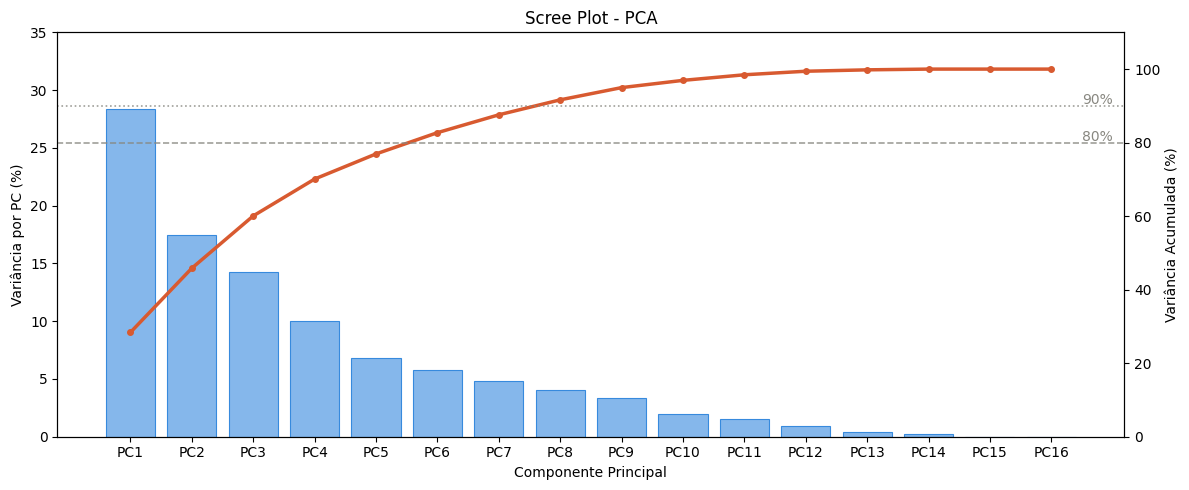


Variância por componente:
PC1: 28.4%  |  Acumulada: 28.4%
PC2: 17.5%  |  Acumulada: 45.8%
PC3: 14.2%  |  Acumulada: 60.1%
PC4: 10.0%  |  Acumulada: 70.1%
PC5: 6.8%  |  Acumulada: 76.9%
PC6: 5.8%  |  Acumulada: 82.7%
PC7: 4.9%  |  Acumulada: 87.6%
PC8: 4.1%  |  Acumulada: 91.6%
PC9: 3.3%  |  Acumulada: 95.0%
PC10: 2.0%  |  Acumulada: 96.9%
PC11: 1.5%  |  Acumulada: 98.5%
PC12: 1.0%  |  Acumulada: 99.4%
PC13: 0.4%  |  Acumulada: 99.8%
PC14: 0.2%  |  Acumulada: 100.0%
PC15: 0.0%  |  Acumulada: 100.0%
PC16: 0.0%  |  Acumulada: 100.0%


In [53]:
import matplotlib.pyplot as plt
import numpy as np

variancia = pca_model_temp.explainedVariance.toArray()
acumulada = variancia.cumsum()
labels = [f"PC{i+1}" for i in range(len(variancia))]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(labels, variancia * 100, color="#85B7EB", edgecolor="#378ADD", linewidth=0.8)
ax1.set_xlabel("Componente Principal")
ax1.set_ylabel("Variância por PC (%)")
ax1.set_ylim(0, 35)

ax2 = ax1.twinx()
ax2.plot(labels, acumulada * 100, "o-", color="#D85A30", linewidth=2.5, markersize=4)
ax2.axhline(y=80, color="#888780", linestyle="--", linewidth=1.2, alpha=0.8)
ax2.axhline(y=90, color="#888780", linestyle=":",  linewidth=1.2, alpha=0.8)
ax2.text(len(labels) - 0.5, 80.5, "80%", fontsize=10, color="#888780")
ax2.text(len(labels) - 0.5, 90.5, "90%", fontsize=10, color="#888780")
ax2.set_ylabel("Variância Acumulada (%)")
ax2.set_ylim(0, 110)

plt.title("Scree Plot - PCA")
plt.tight_layout()
plt.show()

print("\nVariância por componente:")
for i, (v, a) in enumerate(zip(variancia, acumulada)):
    print(f"PC{i+1}: {v*100:.1f}%  |  Acumulada: {a*100:.1f}%")

In [54]:
pca = PCA(k=6, inputCol="features_scaled", outputCol="pca_features")

pipeline = Pipeline(stages=[assembler, scaler, pca])

pipeline_model = pipeline.fit(df_final)

df_pca = pipeline_model.transform(df_final)

In [55]:
df_pca.select("mesorregiao", "ano", "tipo", "pca_features").show(5, truncate=False)

+-------------------------+----+----------------------+----------------------------------------------------------------------------------------------------------------------+
|mesorregiao              |ano |tipo                  |pca_features                                                                                                          |
+-------------------------+----+----------------------+----------------------------------------------------------------------------------------------------------------------+
|Agreste Paraibano (PB)   |2024|Café (em grão) Arábica|[1.1095954439049336,-0.3133272500532275,0.14656717898299165,-2.978811017515192,-1.2552056846684554,0.9601789612244247]|
|Agreste Pernambucano (PE)|2012|Café (em grão) Arábica|[0.9516148458651404,0.18439170916594183,1.8171480255390784,-2.3717092167536586,1.2844743261726854,-1.0078509204329291]|
|Agreste Pernambucano (PE)|2013|Café (em grão) Arábica|[0.9961474763768623,0.07638557337161733,0.8264080376170247,-2.19762195

In [56]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

df_pca = df_pca.withColumn("pca_array", vector_to_array("pca_features"))

for i in range(6):
    df_pca = df_pca.withColumn(f"pc{i+1}", col("pca_array")[i])

df_pca.select("mesorregiao", "ano", "tipo", "pc1", "pc2", "pc3", "pc4", "pc5", "pc6").show(5)

+--------------------+----+--------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+
|         mesorregiao| ano|                tipo|               pc1|                pc2|                pc3|                pc4|                pc5|                pc6|
+--------------------+----+--------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+
|Agreste Paraibano...|2024|Café (em grão) Ar...|1.1095954439049336|-0.3133272500532275|0.14656717898299165| -2.978811017515192|-1.2552056846684554| 0.9601789612244247|
|Agreste Pernambuc...|2012|Café (em grão) Ar...|0.9516148458651404|0.18439170916594183| 1.8171480255390784|-2.3717092167536586| 1.2844743261726854|-1.0078509204329291|
|Agreste Pernambuc...|2013|Café (em grão) Ar...|0.9961474763768623|0.07638557337161733| 0.8264080376170247| -2.197621951571129| 1.2738054841013529|-1.0700436868

In [57]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# Testa k de 2 até 10
wssse_list = []
k_values = range(2, 11)

df_2012 = df_pca.filter(col("ano") == 2012)

for k in k_values:
    kmeans = KMeans(featuresCol="pca_features", predictionCol="cluster", k=k, seed=42)
    model = kmeans.fit(df_2012)
    wssse = model.summary.trainingCost
    wssse_list.append(wssse)
    print(f"k={k} | WSSSE: {wssse:.4f}")

k=2 | WSSSE: 788.6226
k=3 | WSSSE: 614.4696
k=4 | WSSSE: 538.4592
k=5 | WSSSE: 417.7558
k=6 | WSSSE: 383.5052
k=7 | WSSSE: 304.2258
k=8 | WSSSE: 262.1556


k=9 | WSSSE: 237.9707
k=10 | WSSSE: 220.2631


In [58]:
from pyspark.sql.functions import coalesce, lit
from functools import reduce
from pyspark.sql import DataFrame

pca_cols = ["pc1", "pc2", "pc3", "pc4", "pc5", "pc6"]

# configura checkpoint para quebrar o lineage
spark.sparkContext.setCheckpointDir("checkpoint_kmeans")

anos = list(range(2012, 2025))
resultados = []
df_ano_anterior = None

for ano in anos:
    df_ano = df_pca.filter(col("ano") == ano)

    if df_ano_anterior is not None:
        cluster_anterior = df_ano_anterior.select(
            "mesorregiao", "tipo", col("cluster").alias("cluster_anterior")
        )
        df_ano = df_ano.join(cluster_anterior, on=["mesorregiao", "tipo"], how="left")
        df_ano = df_ano.withColumn(
            "cluster_anterior",
            coalesce(col("cluster_anterior").cast("double"), lit(0.0))
        )
        features_ano = pca_cols + ["cluster_anterior"]
    else:
        features_ano = pca_cols

    assembler_ano = VectorAssembler(
        inputCols=features_ano,
        outputCol="features_kmeans",
        handleInvalid="skip"
    )
    df_ano = assembler_ano.transform(df_ano)

    kmeans = KMeans(featuresCol="features_kmeans", predictionCol="cluster", k=5, seed=42)
    model_kmeans = kmeans.fit(df_ano)
    df_ano = model_kmeans.transform(df_ano)

    # materializa e quebra o lineage — resolve o OOM
    df_ano = df_ano.select(
        "mesorregiao", "ano", "tipo",
        "pc1", "pc2", "pc3", "pc4", "pc5", "pc6",
        "cluster"
    ).checkpoint()

    resultados.append(df_ano)
    df_ano_anterior = df_ano

    print(f"Ano {ano} concluído")

df_final_clustered = reduce(DataFrame.union, resultados)
df_final_clustered.show(5)

Ano 2012 concluído


Ano 2013 concluído


Ano 2014 concluído


Ano 2015 concluído
Ano 2016 concluído
Ano 2017 concluído


Ano 2018 concluído
Ano 2019 concluído


Ano 2020 concluído


Ano 2021 concluído


Ano 2022 concluído
Ano 2023 concluído


Ano 2024 concluído
+--------------------+----+--------------------+--------------------+-------------------+--------------------+--------------------+-------------------+-------------------+-------+
|         mesorregiao| ano|                tipo|                 pc1|                pc2|                 pc3|                 pc4|                pc5|                pc6|cluster|
+--------------------+----+--------------------+--------------------+-------------------+--------------------+--------------------+-------------------+-------------------+-------+
|Agreste Pernambuc...|2012|Café (em grão) Ar...|  0.9516148458651404|0.18439170916594183|  1.8171480255390784| -2.3717092167536586| 1.2844743261726854|-1.0078509204329291|      3|
|     Araraquara (SP)|2012|Café (em grão) Ar...|-0.46903803555006185| 1.6217131396835958|  0.4572691646639127|  0.5512343804428083| 0.7260399263368433|-0.6917907187278531|      0|
|      Araçatuba (SP)|2012|Café (em grão) Ar...|  0.4372716126779601| 0.518025532

In [59]:
df_plot = df_final_clustered.select(
    "mesorregiao", "ano", "tipo", "pc1", "pc2", "cluster"
).toPandas()

df_plot["cluster"] = df_plot["cluster"].astype(str)

print(df_plot.shape)
print(df_plot.head())

(1229, 6)
                 mesorregiao   ano                      tipo       pc1  \
0  Agreste Pernambucano (PE)  2012    Café (em grão) Arábica  0.951615   
1            Araraquara (SP)  2012    Café (em grão) Arábica -0.469038   
2             Araçatuba (SP)  2012    Café (em grão) Arábica  0.437272   
3                 Assis (SP)  2012    Café (em grão) Arábica -0.144023   
4        Baixo Amazonas (PA)  2012  Café (em grão) Canephora  3.215213   

        pc2 cluster  
0  0.184392       3  
1  1.621713       0  
2  0.518026       0  
3  0.728132       0  
4 -2.633867       4  


In [60]:
import json

anos = sorted(df_plot["ano"].unique().tolist())
dados_json = {}

for ano in anos:
    df_ano = df_plot[df_plot["ano"] == ano]
    dados_json[str(ano)] = df_ano[["mesorregiao", "pc1", "pc2", "cluster"]].to_dict(orient="records")

print(json.dumps(dados_json["2012"][:3], indent=2))
print("Anos disponíveis:", list(dados_json.keys()))

[
  {
    "mesorregiao": "Agreste Pernambucano (PE)",
    "pc1": 0.9516148458651404,
    "pc2": 0.18439170916594183,
    "cluster": "3"
  },
  {
    "mesorregiao": "Araraquara (SP)",
    "pc1": -0.46903803555006185,
    "pc2": 1.6217131396835958,
    "cluster": "0"
  },
  {
    "mesorregiao": "Ara\u00e7atuba (SP)",
    "pc1": 0.4372716126779601,
    "pc2": 0.5180255323862759,
    "cluster": "0"
  }
]
Anos disponíveis: ['2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


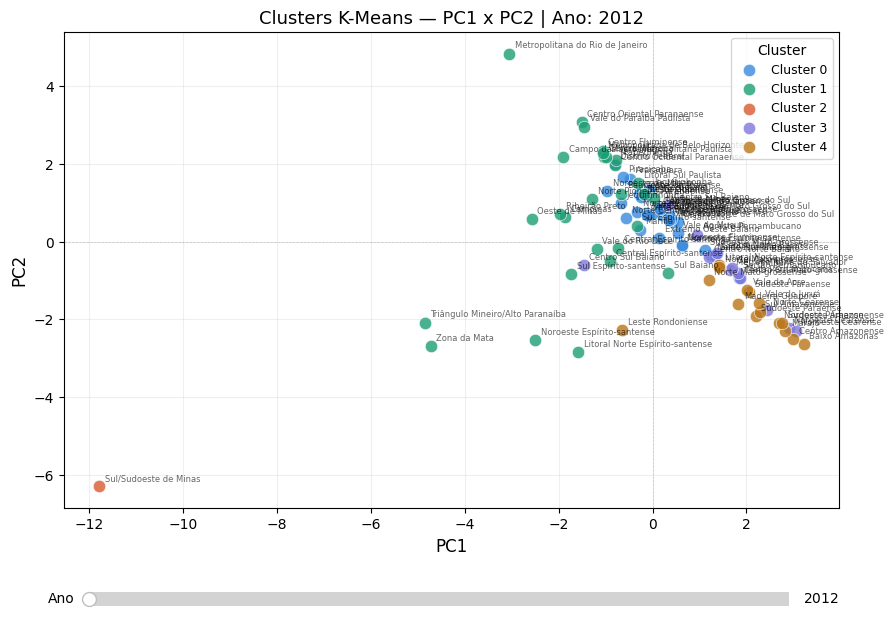

In [61]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

cores = {
    "0": "#378ADD",
    "1": "#1D9E75",
    "2": "#D85A30",
    "3": "#7F77DD",
    "4": "#BA7517"
}

anos = sorted(df_plot["ano"].unique())

fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.2)

def plot_ano(ano):
    ax.clear()
    df_ano = df_plot[df_plot["ano"] == ano]
    
    for cluster_id, cor in cores.items():
        mask = df_ano["cluster"] == cluster_id
        subset = df_ano[mask]
        ax.scatter(
            subset["pc1"], subset["pc2"],
            c=cor, label=f"Cluster {cluster_id}",
            alpha=0.8, edgecolors="white", linewidths=0.5, s=80
        )
        for _, row in subset.iterrows():
            ax.annotate(
                row["mesorregiao"].split(" (")[0],
                (row["pc1"], row["pc2"]),
                fontsize=6, alpha=0.6,
                xytext=(4, 4), textcoords="offset points"
            )
    
    ax.set_xlabel("PC1", fontsize=12)
    ax.set_ylabel("PC2", fontsize=12)
    ax.set_title(f"Clusters K-Means — PC1 x PC2 | Ano: {ano}", fontsize=13)
    ax.legend(title="Cluster", loc="upper right", fontsize=9)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", alpha=0.4)
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--", alpha=0.4)
    ax.grid(True, alpha=0.2)
    fig.canvas.draw_idle()

from matplotlib.widgets import Slider

ax_slider = plt.axes([0.15, 0.05, 0.7, 0.04])
slider = Slider(
    ax=ax_slider,
    label="Ano",
    valmin=anos[0],
    valmax=anos[-1],
    valinit=anos[0],
    valstep=1,
    color="#378ADD"
)

slider.on_changed(lambda val: plot_ano(int(val)))

plot_ano(anos[0])
plt.show()

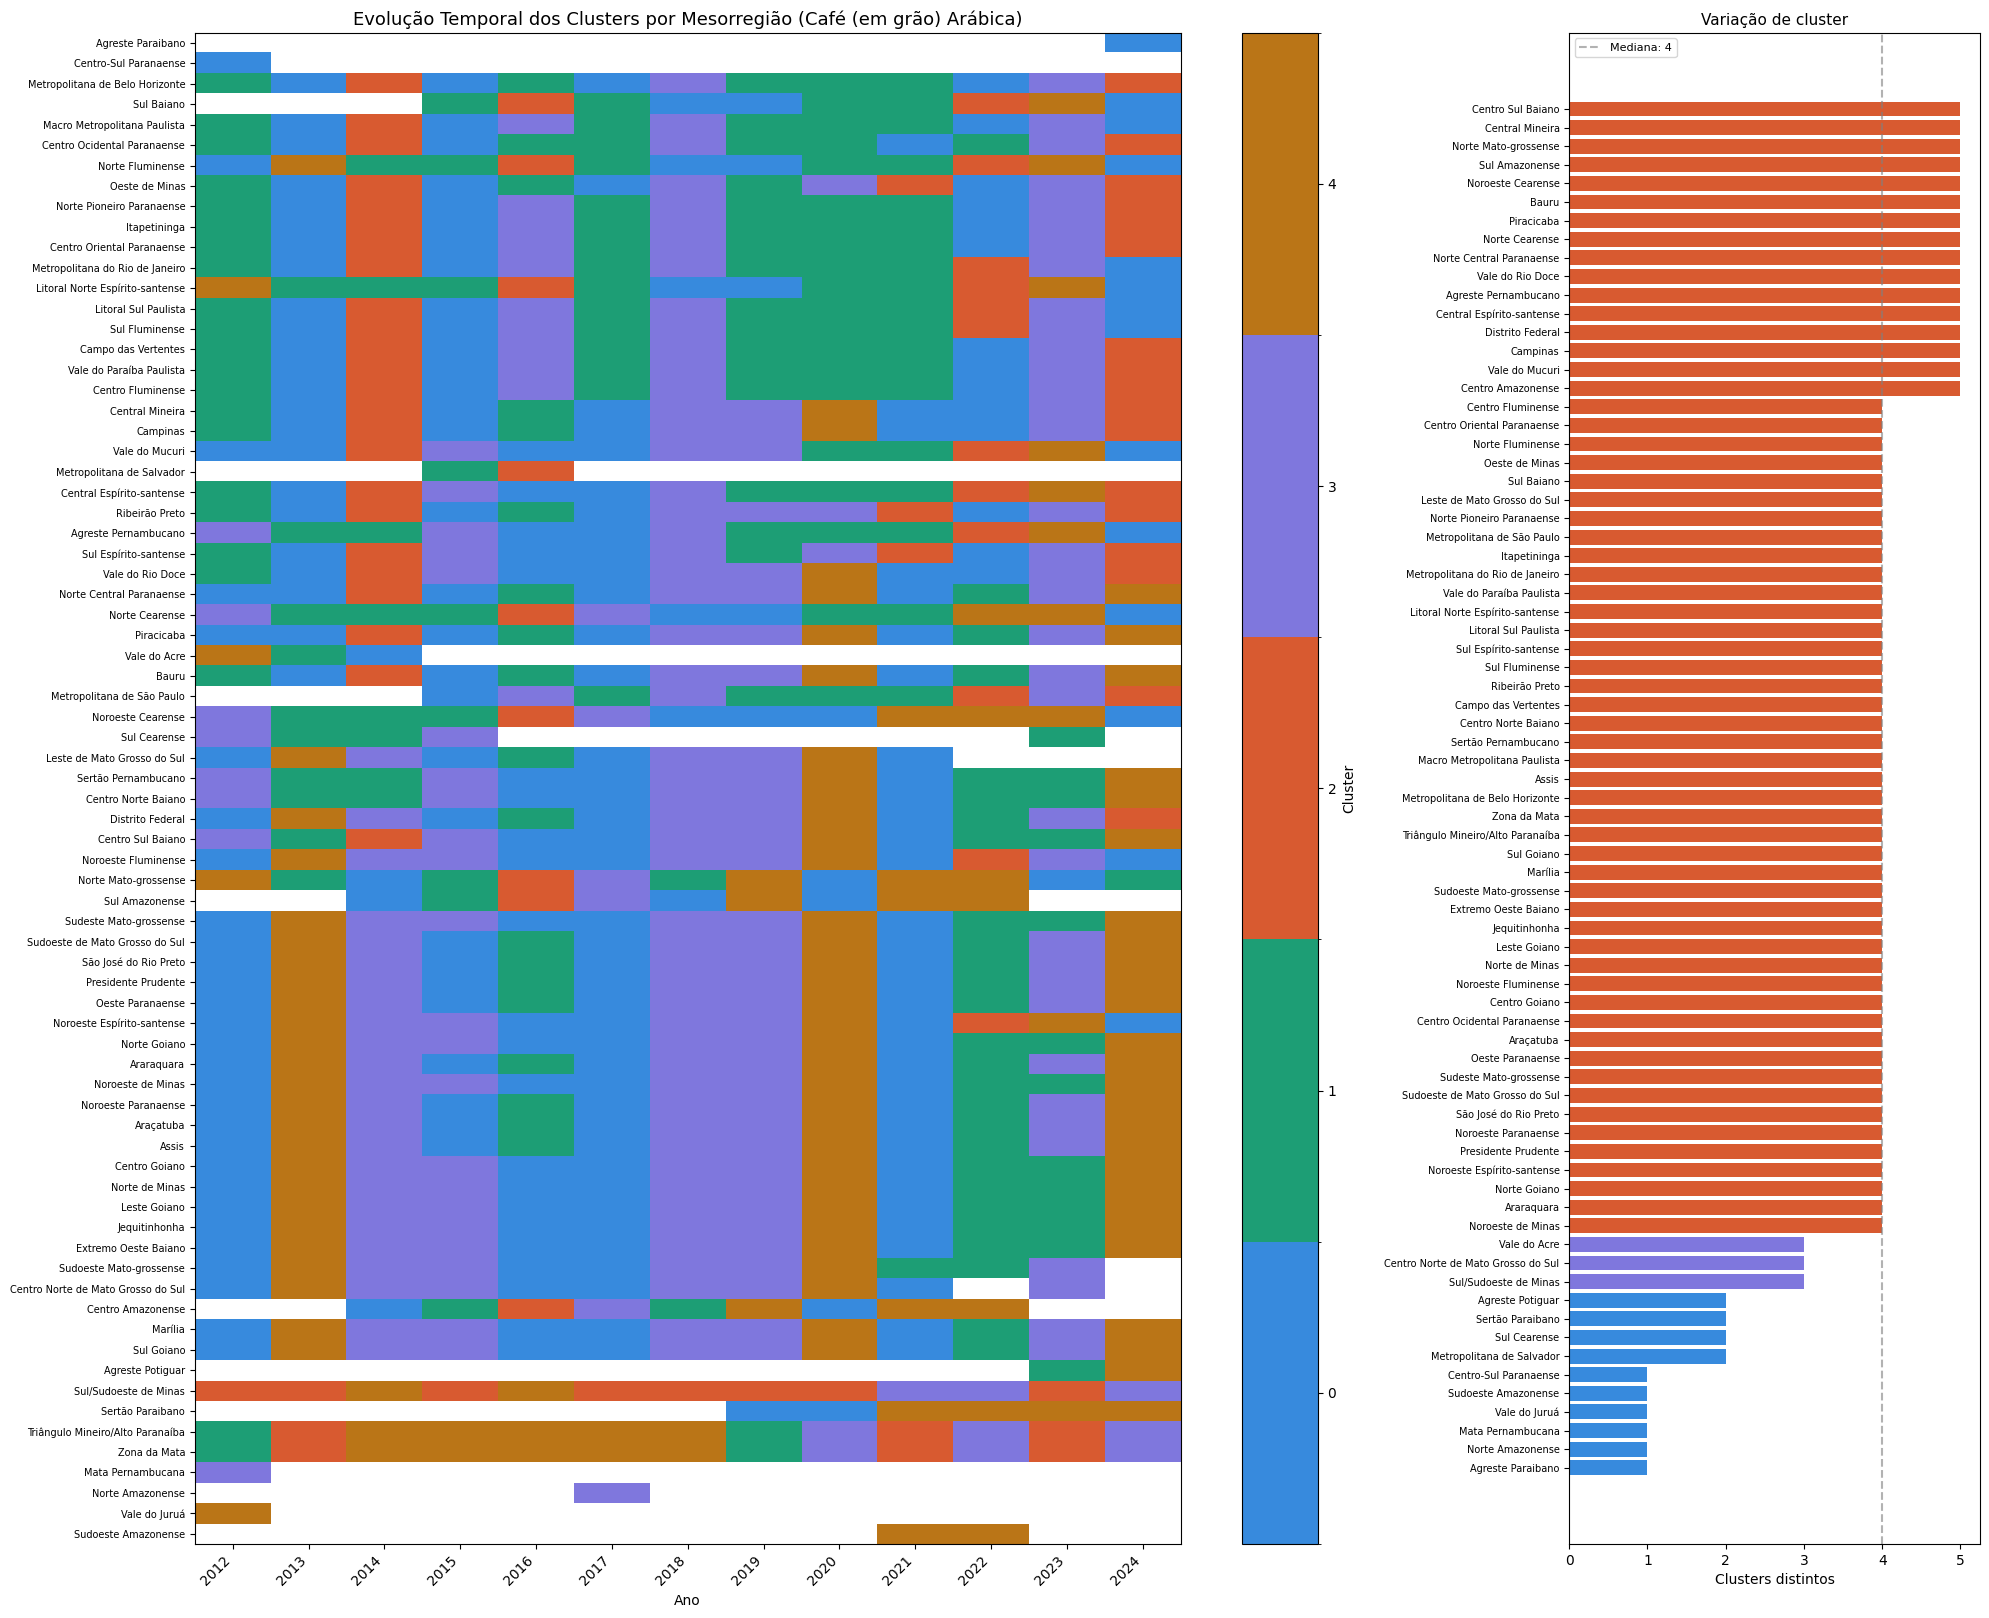


=== Top 10 mesorregiões com maior variação de cluster ===
mesorregiao
Centro Sul Baiano (BA)            5
Norte Central Paranaense (PR)     5
Centro Amazonense (AM)            5
Vale do Mucuri (MG)               5
Campinas (SP)                     5
Distrito Federal (DF)             5
Agreste Pernambucano (PE)         5
Vale do Rio Doce (MG)             5
Central Espírito-santense (ES)    5
Norte Cearense (CE)               5

=== Top 10 mesorregiões mais estáveis ===
mesorregiao
Agreste Paraibano (PB)            1
Norte Amazonense (AM)             1
Mata Pernambucana (PE)            1
Vale do Juruá (AC)                1
Sudoeste Amazonense (AM)          1
Centro-Sul Paranaense (PR)        1
Metropolitana de Salvador (BA)    2
Sul Cearense (CE)                 2
Sertão Paraibano (PB)             2
Agreste Potiguar (RN)             2


In [62]:

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

cores = {"0": "#378ADD", "1": "#1D9E75", "2": "#D85A30", "3": "#7F77DD", "4": "#BA7517"}

tipo_ref = df_plot["tipo"].unique()[0]
df_arb = df_plot[df_plot["tipo"] == tipo_ref].copy()
df_arb["cluster_num"] = df_arb["cluster"].astype(int)
pivot = df_arb.pivot_table(index="mesorregiao", columns="ano", values="cluster_num", aggfunc="first")
pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

fig, axes = plt.subplots(1, 2, figsize=(20, max(8, len(pivot) * 0.22)),
                         gridspec_kw={"width_ratios": [3, 1]})

cmap = mcolors.ListedColormap(["#378ADD", "#1D9E75", "#D85A30", "#7F77DD", "#BA7517"])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

im = axes[0].imshow(pivot.values, aspect="auto", cmap=cmap, norm=norm)
axes[0].set_xticks(range(len(pivot.columns)))
axes[0].set_xticklabels(pivot.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(pivot.index)))
axes[0].set_yticklabels([m.split(" (")[0] for m in pivot.index], fontsize=7)
axes[0].set_xlabel("Ano")
axes[0].set_title(f"Evolução Temporal dos Clusters por Mesorregião ({tipo_ref})", fontsize=13)
plt.colorbar(im, ax=axes[0], ticks=[0, 1, 2, 3, 4], label="Cluster")

mudancas = pivot.apply(lambda row: row.nunique(), axis=1).sort_values(ascending=True)
cores_barra = ["#D85A30" if v >= 4 else "#378ADD" if v <= 2 else "#7F77DD" for v in mudancas.values]
axes[1].barh([m.split(" (")[0] for m in mudancas.index], mudancas.values, color=cores_barra)
axes[1].set_xlabel("Clusters distintos")
axes[1].set_title("Variação de cluster", fontsize=11)
axes[1].axvline(mudancas.median(), color="gray", linestyle="--", alpha=0.6,
                label=f"Mediana: {mudancas.median():.0f}")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

print("\n=== Top 10 mesorregiões com maior variação de cluster ===")
print(mudancas.sort_values(ascending=False).head(10).to_string())
print("\n=== Top 10 mesorregiões mais estáveis ===")
print(mudancas.sort_values().head(10).to_string())

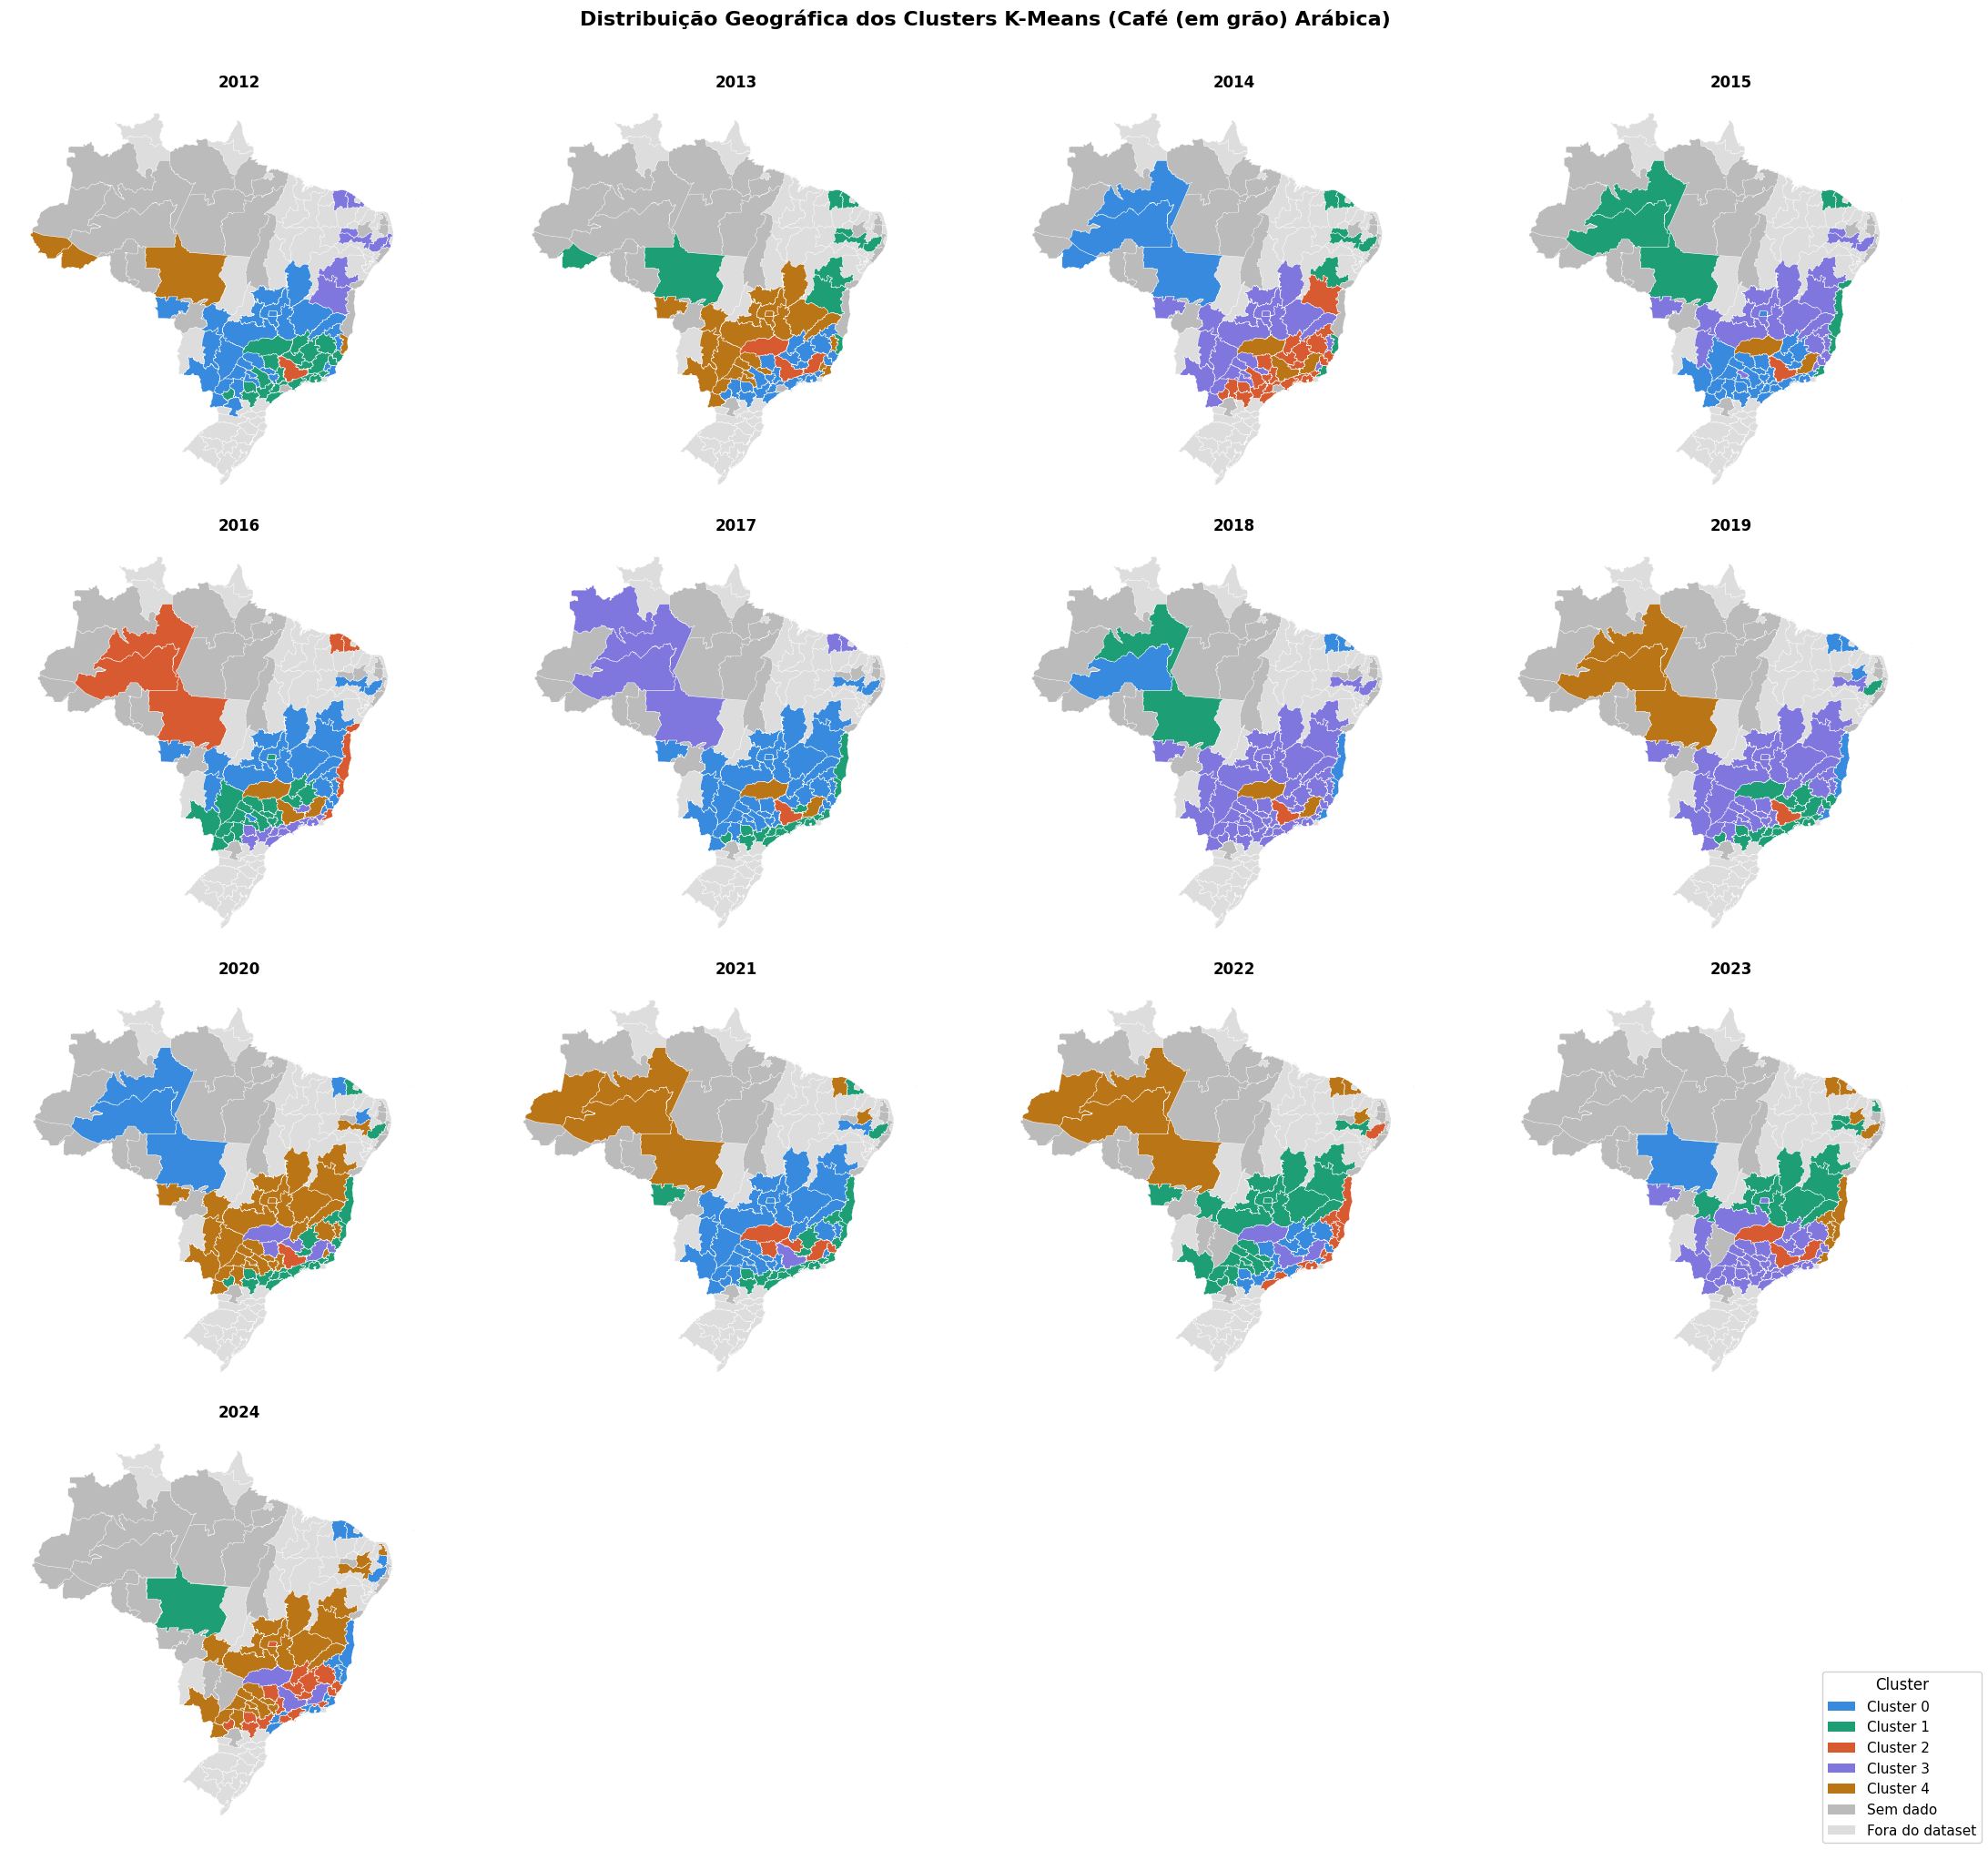

In [63]:


import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

caminho_shapefile = "dados-brutos/centroides/BR_Mesorregioes_2022/BR_Mesorregioes_2022.shp"
gdf = gpd.read_file(caminho_shapefile)
gdf["mesorregiao"] = gdf["NM_MESO"] + " (" + gdf["SIGLA_UF"] + ")"

cores_mapa = {"0": "#378ADD", "1": "#1D9E75", "2": "#D85A30", "3": "#7F77DD", "4": "#BA7517"}

tipo_ref = df_plot["tipo"].unique()[0]
anos_mapa = sorted(df_plot["ano"].unique())
n_cols = 4
n_rows = -(-len(anos_mapa) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 5))
axes = axes.flatten()

regioes_no_dataset = set(df_plot["mesorregiao"].unique())

for idx, ano in enumerate(anos_mapa):
    ax = axes[idx]
    df_ano = df_plot[(df_plot["ano"] == ano) & (df_plot["tipo"] == tipo_ref)]
    gdf_ano = gdf.merge(df_ano[["mesorregiao", "cluster"]], on="mesorregiao", how="left")

    gdf_ano[~gdf_ano["mesorregiao"].isin(regioes_no_dataset)].plot(
        ax=ax, color="#DDDDDD", edgecolor="white", linewidth=0.2)

    gdf_ano[gdf_ano["mesorregiao"].isin(regioes_no_dataset) & gdf_ano["cluster"].isna()].plot(
        ax=ax, color="#BBBBBB", edgecolor="white", linewidth=0.2)

    for cluster_id, cor in cores_mapa.items():
        subset = gdf_ano[gdf_ano["cluster"] == cluster_id]
        if not subset.empty:
            subset.plot(ax=ax, color=cor, edgecolor="white", linewidth=0.3)

    ax.set_title(str(ano), fontsize=12, fontweight="bold")
    ax.axis("off")

for idx in range(len(anos_mapa), len(axes)):
    axes[idx].axis("off")

legend_elements = [Patch(facecolor=cor, label=f"Cluster {k}") for k, cor in cores_mapa.items()]
legend_elements.append(Patch(facecolor="#BBBBBB", label="Sem dado"))
legend_elements.append(Patch(facecolor="#DDDDDD", label="Fora do dataset"))
fig.legend(handles=legend_elements, loc="lower right", fontsize=11,
           title="Cluster", title_fontsize=12, framealpha=0.9)

fig.suptitle(f"Distribuição Geográfica dos Clusters K-Means ({tipo_ref})",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

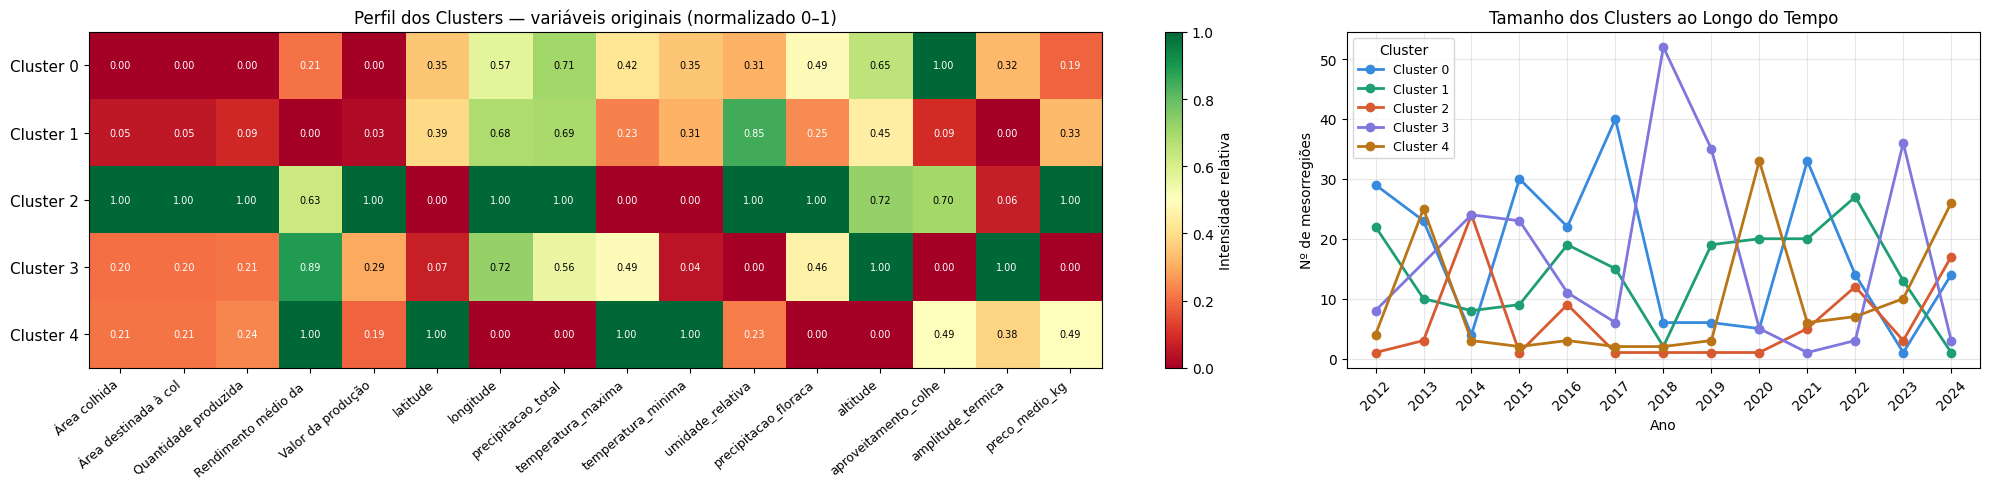


=== Perfil absoluto por cluster (médias) ===
cluster                          0             1             2             3             4
Área colhida          1.132415e+04  1.380757e+04  5.832991e+04  2.092753e+04  2.130529e+04
Área destinada à col  1.138221e+04  1.384821e+04  5.842907e+04  2.096398e+04  2.133043e+04
Quantidade produzida  1.588956e+07  2.284817e+07  9.724881e+07  3.310609e+07  3.550553e+07
Rendimento médio da   1.393820e+03  1.367840e+03  1.445280e+03  1.477890e+03  1.491620e+03
Valor da produção     1.330133e+08  1.550571e+08  9.512845e+08  3.731550e+08  2.849945e+08
latitude             -1.683000e+01 -1.669000e+01 -1.818000e+01 -1.792000e+01 -1.433000e+01
longitude            -4.795000e+01 -4.744000e+01 -4.601000e+01 -4.725000e+01 -5.049000e+01
precipitacao_total    1.032520e+03  1.030750e+03  1.073340e+03  1.011510e+03  9.343700e+02
temperatura_maxima    2.980000e+01  2.945000e+01  2.902000e+01  2.992000e+01  3.089000e+01
temperatura_minima    1.909000e+01  1.903000

In [64]:

import pandas as pd
import matplotlib.pyplot as plt

cols_perfil = feature_cols  # definido na célula de feature engineering

df_cluster_orig = (
    df_final_clustered
    .select("mesorregiao", "ano", "tipo", "cluster")
    .join(df_final.select(["mesorregiao", "ano", "tipo"] + cols_perfil),
          on=["mesorregiao", "ano", "tipo"], how="left")
    .toPandas()
)
df_cluster_orig["cluster"] = df_cluster_orig["cluster"].astype(str)

label_map = {c: c.split(" - ")[-1].split(" (")[0][:20] for c in cols_perfil}

perfil = df_cluster_orig.groupby("cluster")[cols_perfil].mean()
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min() + 1e-9)
perfil_norm.columns = [label_map.get(c, c) for c in perfil_norm.columns]

fig, axes = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={"width_ratios": [2, 1]})

# Heatmap de perfil
im = axes[0].imshow(perfil_norm.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
axes[0].set_xticks(range(len(perfil_norm.columns)))
axes[0].set_xticklabels(perfil_norm.columns, rotation=40, ha="right", fontsize=9)
axes[0].set_yticks(range(len(perfil_norm.index)))
axes[0].set_yticklabels([f"Cluster {c}" for c in perfil_norm.index], fontsize=11)
axes[0].set_title("Perfil dos Clusters — variáveis originais (normalizado 0–1)", fontsize=12)
plt.colorbar(im, ax=axes[0], label="Intensidade relativa")

for i in range(len(perfil_norm.index)):
    for j in range(len(perfil_norm.columns)):
        val = perfil_norm.values[i, j]
        txt_color = "white" if val > 0.75 or val < 0.25 else "black"
        axes[0].text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=txt_color)

# Tamanho dos clusters ao longo do tempo
tipo_ref2 = df_plot["tipo"].unique()[0]
contagem = (df_plot[df_plot["tipo"] == tipo_ref2]
            .groupby(["ano", "cluster"]).size().reset_index(name="count"))

cores_plot = {"0": "#378ADD", "1": "#1D9E75", "2": "#D85A30", "3": "#7F77DD", "4": "#BA7517"}
for cluster_id, cor in cores_plot.items():
    sub = contagem[contagem["cluster"] == cluster_id]
    if not sub.empty:
        axes[1].plot(sub["ano"], sub["count"], marker="o", color=cor,
                    label=f"Cluster {cluster_id}", linewidth=2)

axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Nº de mesorregiões")
axes[1].set_title("Tamanho dos Clusters ao Longo do Tempo", fontsize=12)
axes[1].legend(title="Cluster", fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(sorted(df_plot["ano"].unique()))
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("\n=== Perfil absoluto por cluster (médias) ===")
perfil_display = perfil.copy()
perfil_display.columns = [label_map.get(c, c) for c in perfil_display.columns]
print(perfil_display.round(2).T.to_string())

In [65]:
# KMeans global: clusters consistentes entre anos
# Treina um único modelo com todos os anos juntos.
# Assim, cluster 0, 1, 2... mantêm a mesma interpretação ao longo do tempo.

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.sql.functions import col

pca_cols = ["pc1", "pc2", "pc3", "pc4", "pc5", "pc6"]

assembler_global = VectorAssembler(
    inputCols=pca_cols,
    outputCol="features_kmeans_global",
    handleInvalid="skip"
)

df_kmeans_global = assembler_global.transform(df_pca)

kmeans_global = KMeans(
    featuresCol="features_kmeans_global",
    predictionCol="cluster_global",
    k=5,
    seed=42
)

model_kmeans_global = kmeans_global.fit(df_kmeans_global)

df_final_clustered_global = model_kmeans_global.transform(df_kmeans_global).select(
    "mesorregiao", "ano", "tipo",
    "pc1", "pc2", "pc3", "pc4", "pc5", "pc6",
    col("cluster_global").alias("cluster")
)

df_plot_global = df_final_clustered_global.select(
    "mesorregiao", "ano", "tipo", "pc1", "pc2", "cluster"
).toPandas()

df_plot_global["cluster"] = df_plot_global["cluster"].astype(str)

print(df_plot_global.shape)
print(df_plot_global.head())

df_final_clustered_global.groupBy("ano", "cluster").count().orderBy("ano", "cluster").show(100)

(1229, 6)
                 mesorregiao   ano                    tipo       pc1  \
0     Agreste Paraibano (PB)  2024  Café (em grão) Arábica  1.109595   
1  Agreste Pernambucano (PE)  2012  Café (em grão) Arábica  0.951615   
2  Agreste Pernambucano (PE)  2013  Café (em grão) Arábica  0.996147   
3  Agreste Pernambucano (PE)  2014  Café (em grão) Arábica  0.962652   
4  Agreste Pernambucano (PE)  2015  Café (em grão) Arábica  1.039514   

        pc2 cluster  
0 -0.313327       1  
1  0.184392       1  
2  0.076386       1  
3  0.133809       1  
4  0.063677       1  
+----+-------+-----+
| ano|cluster|count|
+----+-------+-----+
|2012|      0|   27|
|2012|      1|   18|
|2012|      2|    3|
|2012|      3|   27|
|2012|      4|   17|
|2013|      0|   38|
|2013|      1|   14|
|2013|      2|    3|
|2013|      3|   18|
|2013|      4|   16|
|2014|      0|   18|
|2014|      1|   20|
|2014|      2|    3|
|2014|      3|   35|
|2014|      4|   16|
|2015|      0|   24|
|2015|      1|   28|
|2015

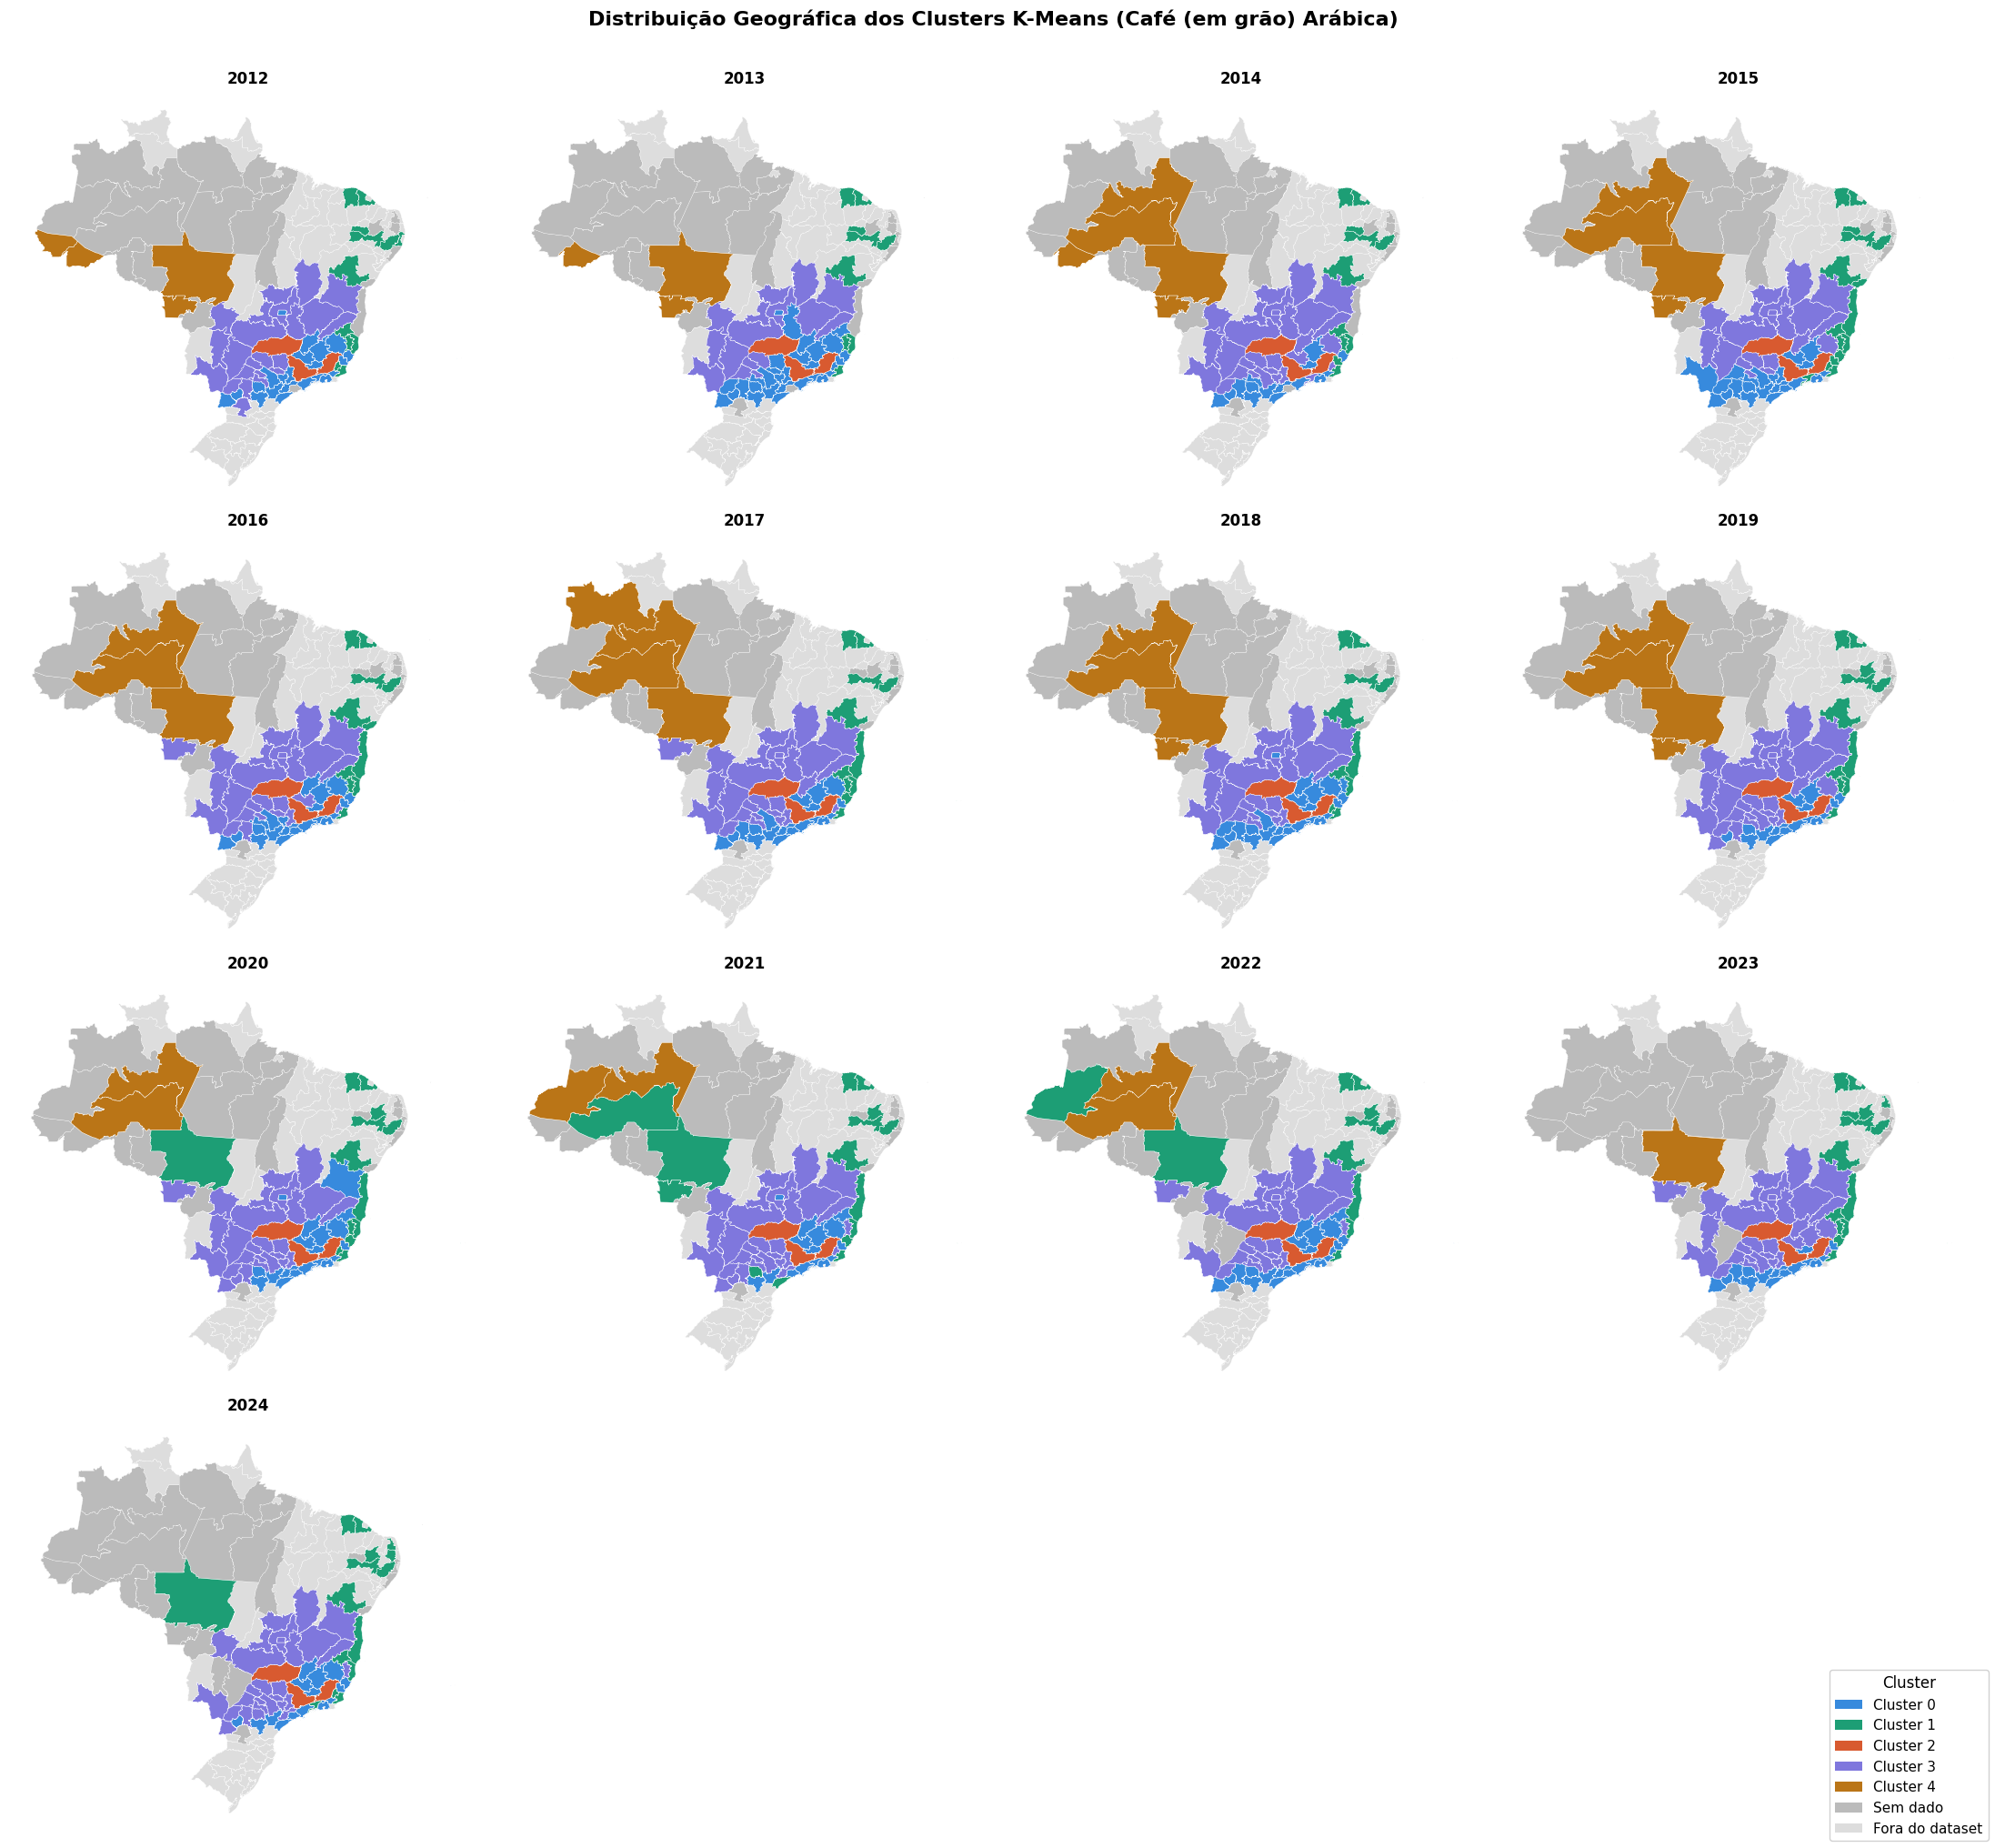

In [66]:
df_plot = df_plot_global.copy()
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

caminho_shapefile = "dados-brutos/centroides/BR_Mesorregioes_2022/BR_Mesorregioes_2022.shp"
gdf = gpd.read_file(caminho_shapefile)
gdf["mesorregiao"] = gdf["NM_MESO"] + " (" + gdf["SIGLA_UF"] + ")"

cores_mapa = {"0": "#378ADD", "1": "#1D9E75", "2": "#D85A30", "3": "#7F77DD", "4": "#BA7517"}

tipo_ref = df_plot["tipo"].unique()[0]
anos_mapa = sorted(df_plot["ano"].unique())
n_cols = 4
n_rows = -(-len(anos_mapa) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 5))
axes = axes.flatten()

regioes_no_dataset = set(df_plot["mesorregiao"].unique())

for idx, ano in enumerate(anos_mapa):
    ax = axes[idx]
    df_ano = df_plot[(df_plot["ano"] == ano) & (df_plot["tipo"] == tipo_ref)]
    gdf_ano = gdf.merge(df_ano[["mesorregiao", "cluster"]], on="mesorregiao", how="left")

    gdf_ano[~gdf_ano["mesorregiao"].isin(regioes_no_dataset)].plot(
        ax=ax, color="#DDDDDD", edgecolor="white", linewidth=0.2)

    gdf_ano[gdf_ano["mesorregiao"].isin(regioes_no_dataset) & gdf_ano["cluster"].isna()].plot(
        ax=ax, color="#BBBBBB", edgecolor="white", linewidth=0.2)

    for cluster_id, cor in cores_mapa.items():
        subset = gdf_ano[gdf_ano["cluster"] == cluster_id]
        if not subset.empty:
            subset.plot(ax=ax, color=cor, edgecolor="white", linewidth=0.3)

    ax.set_title(str(ano), fontsize=12, fontweight="bold")
    ax.axis("off")

for idx in range(len(anos_mapa), len(axes)):
    axes[idx].axis("off")

legend_elements = [Patch(facecolor=cor, label=f"Cluster {k}") for k, cor in cores_mapa.items()]
legend_elements.append(Patch(facecolor="#BBBBBB", label="Sem dado"))
legend_elements.append(Patch(facecolor="#DDDDDD", label="Fora do dataset"))
fig.legend(handles=legend_elements, loc="lower right", fontsize=11,
           title="Cluster", title_fontsize=12, framealpha=0.9)

fig.suptitle(f"Distribuição Geográfica dos Clusters K-Means ({tipo_ref})",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [67]:
# Resumo quantitativo dos clusters globais
# Usa o resultado do KMeans global já calculado em df_plot_global.

resumo_clusters_global = (
    df_plot_global
    .groupby("cluster")
    .agg(
        quantidade=("mesorregiao", "count"),
        pc1_medio=("pc1", "mean"),
        pc2_medio=("pc2", "mean"),
        anos_distintos=("ano", "nunique")
    )
    .sort_index()
)

print(resumo_clusters_global)

# Quantidade de observações por ano e cluster: ajuda a discutir estabilidade/mudança temporal.
distribuicao_anual_clusters = (
    df_plot_global
    .groupby(["ano", "cluster"])
    .size()
    .unstack(fill_value=0)
)

print(distribuicao_anual_clusters)

         quantidade  pc1_medio  pc2_medio  anos_distintos
cluster                                                  
0               326  -0.943723   1.384244              13
1               267   1.293282  -1.039987              13
2                42  -7.560811  -4.127181              13
3               424  -0.209101   0.704647              13
4               170   2.168002  -1.758917              13
cluster   0   1  2   3   4
ano                       
2012     27  18  3  27  17
2013     38  14  3  18  16
2014     18  20  3  35  16
2015     24  28  3  26  14
2016     27  19  3  31  15
2017     23  21  3  33  15
2018     33  14  3  29  16
2019     21  17  3  39  16
2020     26  22  3  33  12
2021     20  28  3  38   7
2022     31  18  4  33  10
2023     19  24  3  41   9
2024     19  24  5  41   7


## Análise revisada com KMeans global

Na primeira visualização anual, os clusters eram recalculados separadamente para cada ano. Isso tornava a leitura temporal menos confiável, porque o rótulo `cluster 0` de um ano não necessariamente representava o mesmo perfil do `cluster 0` em outro ano. Para corrigir essa limitação, foi adicionado um KMeans global, treinado uma única vez com todos os anos juntos. Assim, as cores passam a representar perfis consistentes ao longo da série temporal.

Com o KMeans global, a comparação entre mapas anuais fica mais adequada: quando uma mesorregião muda de cor, isso indica uma mudança de perfil em relação ao conjunto completo dos dados, e não apenas uma renumeração arbitrária do KMeans. Dessa forma, a análise temporal fica mais defensável, pois os clusters deixam de ser apenas agrupamentos internos de cada ano e passam a representar padrões gerais da base.

A leitura dos clusters deve ser feita em conjunto com os componentes principais. Como os seis primeiros componentes do PCA concentram aproximadamente 82,7% da variância, o KMeans global agrupa as observações usando uma representação compacta das variáveis agrícolas, climáticas e geográficas. Regiões próximas no espaço de PCA tendem a ter produção, área, rendimento, valor econômico, localização e clima mais semelhantes.

Os mapas e gráficos resultantes indicam que a cafeicultura brasileira apresenta perfis regionais distintos. Algumas mesorregiões permanecem em perfis semelhantes ao longo dos anos, sugerindo estabilidade produtiva e climática. Outras mudam de cluster, o que pode indicar alteração relativa em produtividade, valor da produção, área plantada/colhida ou condições climáticas. Essa transição entre clusters é justamente o principal ganho da abordagem global: ela permite observar mudanças temporais mantendo uma referência comum entre todos os anos.

Portanto, o resultado final mostra que PCA e KMeans se complementam: o PCA reduz a dimensionalidade e organiza a informação principal da base, enquanto o KMeans identifica perfis de mesorregiões produtoras de café. Com o modelo global, esses perfis podem ser comparados ao longo do tempo, tornando a discussão dos padrões encontrados mais consistente.

# Resumo do projeto


Este trabalho utiliza uma base sobre produção de café por mesorregião brasileira, combinando atributos agrícolas, geográficos e climáticos. A base final possui mais de 500 amostras e mais de 4 atributos numéricos, atendendo ao requisito mínimo do enunciado. Todo o processamento principal foi feito com Spark/PySpark, incluindo criação dos DataFrames, junções, tratamento de valores ausentes, montagem dos vetores de atributos, padronização, PCA e KMeans.


## Aplicação e explicação do PCA

O PCA foi aplicado sobre 16 atributos numéricos padronizados com `StandardScaler`. A padronização é importante porque os atributos estão em escalas muito diferentes, como área em hectares, produção em quilogramas, valor em reais, coordenadas geográficas e variáveis climáticas. Sem essa etapa, variáveis de maior magnitude poderiam dominar artificialmente os componentes principais.

O PCA transforma os atributos originais em novas dimensões chamadas componentes principais. Cada componente é uma combinação linear das variáveis originais e busca explicar a maior quantidade possível de variância dos dados. No resultado obtido, os seis primeiros componentes explicam aproximadamente 82,7% da variância acumulada: PC1 explica 28,4%, PC2 17,5%, PC3 14,2%, PC4 10,0%, PC5 6,8% e PC6 5,8%. Por isso, foram usados 6 componentes no modelo final, reduzindo a dimensionalidade sem descartar a maior parte da informação.


## Aplicação e explicação do agrupamento

O algoritmo de agrupamento utilizado foi o KMeans, implementado pelo `pyspark.ml.clustering.KMeans`. O KMeans separa as amostras em grupos a partir da proximidade entre seus vetores de atributos. Neste trabalho, os vetores usados pelo KMeans foram os componentes principais gerados pelo PCA, o que reduz ruído, diminui a redundância entre variáveis e torna o agrupamento mais estável.

Foram testados valores de `k` entre 2 e 10 usando WSSSE, que mede a soma dos erros quadráticos dentro dos clusters. Em geral, quanto menor o WSSSE, mais compactos são os grupos, mas valores muito altos de `k` podem gerar uma divisão excessivamente específica. O notebook mostra queda progressiva do WSSSE, e foi adotado `k=5` para representar cinco perfis principais de mesorregiões/anos/tipos de café. O agrupamento foi aplicado por ano, permitindo comparar como os padrões mudam ao longo do tempo.


## Discussão dos padrões encontrados

A projeção dos dados nos dois primeiros componentes principais mostra que as observações não ficam distribuídas de forma aleatória: há regiões concentradas próximas umas das outras e pontos mais afastados. Isso indica que existem perfis produtivos e climáticos diferentes entre as mesorregiões produtoras de café.

Os clusters tendem a separar mesorregiões com combinações semelhantes de produção, área, rendimento, valor econômico, localização e clima. Grupos mais próximos no gráfico PCA representam regiões com comportamento produtivo parecido, enquanto grupos mais afastados sugerem realidades mais distintas. A presença de café arábica e canephora também contribui para a separação, já que esses tipos costumam estar associados a condições climáticas e regiões produtoras diferentes.

Assim, o padrão principal encontrado é que a produção de café no Brasil pode ser organizada em perfis regionais: algumas mesorregiões apresentam comportamento mais próximo de produção consolidada e alto valor/volume, outras se agrupam por características climáticas e geográficas, e outras aparecem como casos mais específicos ou extremos. O uso conjunto de PCA e KMeans ajudou a resumir muitas variáveis em poucos eixos interpretáveis e a identificar esses perfis sem depender de rótulos prévios.
